## Importing necessary libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import regularizers
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline 

## Exploring the dataset

In [3]:

# Read Train and Test dataset
data_train = pd.read_csv("nsl-kdd/KDDTrain+.txt")

In [4]:
# Check data
data_train.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.18,2,2.1,0.00,0.00.1,0.00.2,0.00.3,1.00,0.00.4,0.00.5,150,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [5]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

In [6]:
# Assign name for columns
data_train.columns = columns

In [7]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [8]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [9]:
data_train.describe().style.background_gradient(cmap='Blues').set_properties(**{'font-family':'Segoe UI'})

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,45567.100824,19779.271433,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,0.001342,0.001103,0.302194,0.012669,0.000413,0.004096,0.000000,0.000008,0.009423,84.108207,27.738093,0.284487,0.282488,0.119959,0.121184,0.660925,0.063053,0.097322,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5870354.480801,4021285.112114,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,0.036603,0.045155,24.399715,0.483937,0.022181,0.099370,0.000000,0.002817,0.096613,114.508828,72.636092,0.446457,0.447024,0.320437,0.323648,0.439624,0.180315,0.259831,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,276.000000,516.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1379963888.000000,1309937401.000000,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [10]:
data_train.loc[data_train['outcome'] == "normal", "outcome"] = 'normal'
data_train.loc[data_train['outcome'] != 'normal', "outcome"] = 'attack'

In [11]:
def pie_plot(df, cols_list, rows, cols):
    fig, axes = plt.subplots(rows, cols)
    for ax, col in zip(axes.ravel(), cols_list):
        df[col].value_counts().plot(ax=ax, kind='pie', figsize=(15, 15), fontsize=10, autopct='%1.0f%%')
        ax.set_title(str(col), fontsize = 12)
    plt.show()

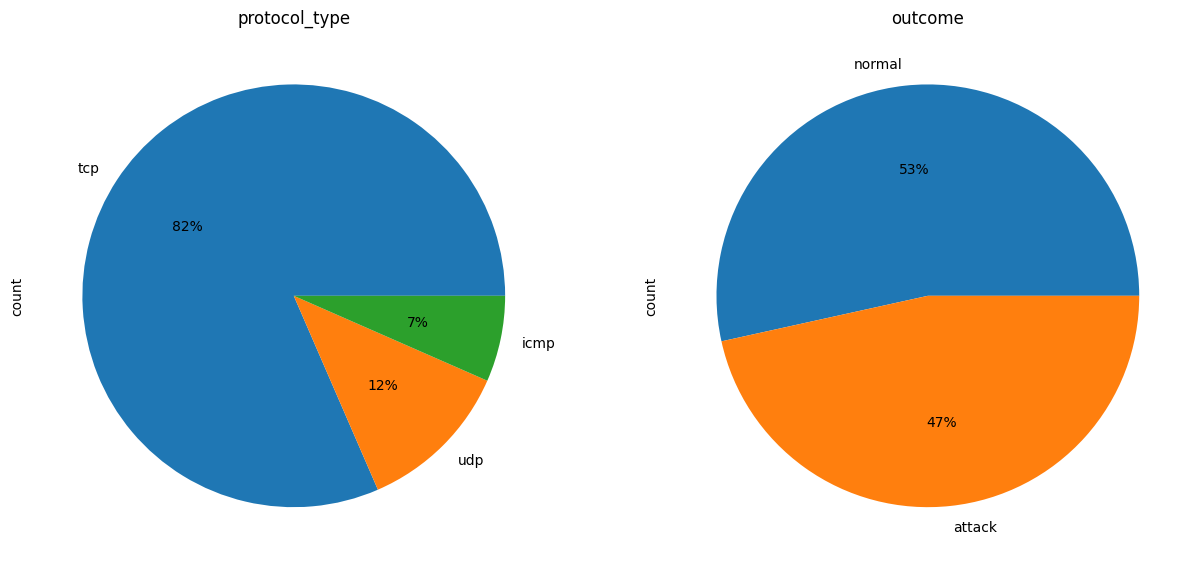

In [12]:
pie_plot(data_train, ['protocol_type', 'outcome'], 1, 2)




## Preprocessing the data

In [13]:
def Scaling(df_num, cols):
    std_scaler = RobustScaler()
    std_scaler_temp = std_scaler.fit_transform(df_num)
    std_df = pd.DataFrame(std_scaler_temp, columns =cols)
    return std_df

In [14]:
cat_cols = ['is_host_login','protocol_type','service','flag','land', 'logged_in','is_guest_login', 'level', 'outcome']
def preprocess(dataframe):
    df_num = dataframe.drop(cat_cols, axis=1)
    num_cols = df_num.columns
    scaled_df = Scaling(df_num, num_cols)
    
    dataframe.drop(labels=num_cols, axis="columns", inplace=True)
    dataframe[num_cols] = scaled_df[num_cols]
    dataframe.dropna(inplace=True)
    dataframe.drop_duplicates(inplace=True)
    
    dataframe.loc[dataframe['outcome'] == "normal", "outcome"] = 0
    dataframe.loc[dataframe['outcome'] != 0, "outcome"] = 1
    
    dataframe = pd.get_dummies(dataframe, columns = ['protocol_type', 'service', 'flag'])
    
    # this is a test
    return dataframe

In [15]:

scaled_train = preprocess(data_train)
scaled_train

,land,logged_in,is_host_login,is_guest_login,outcome,level,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_harvest,service_hostnames,service_http,service_http_2784,service_http_443,service_http_8001,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,15,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.007092,-0.4375,0.0,0.0,0.0,0.0,-1.010989,2.500000,0.00,0.000000,-0.253061,-0.536842,8.285714,14.666667,0.0,0.00,0.00,0.00,0.00,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,1,19,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.773050,-0.1250,1.0,1.0,0.0,0.0,-1.043956,1.166667,0.00,0.000000,-0.151020,-0.431579,0.428571,0.000000,0.0,1.00,1.00,0.00,0.00,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,0,1,0,0,0,21,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.063830,-0.1875,0.2,0.2,0.0,0.0,0.000000,0.000000,0.00,-1.300578,0.783673,0.515789,-0.285714,0.500000,2.0,0.03,0.01,0.00,0.01,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,1,0,0,0,21,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [16]:
x = scaled_train.drop(['outcome', 'level'] , axis = 1).values
y = scaled_train['outcome'].values
y_reg = scaled_train['level'].values

pca = PCA(n_components=20)
pca = pca.fit(x)
x_reduced = pca.transform(x)
print("Number of original features is {} and of reduced features is {}".format(x.shape[1], x_reduced.shape[1]))

y = y.astype('int')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, y, test_size=0.2, random_state=42)
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size=0.2, random_state=42)

Number of original features is 122 and of reduced features is 20


## ***Evaluate ML Models Function***

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_classification_RF(model, name, X_train, X_test, y_train, y_test):
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Compute confusion matrix for both train and test sets
    train_confusion_matrix = metrics.confusion_matrix(y_train, train_pred)
    test_confusion_matrix = metrics.confusion_matrix(y_test, test_pred)

    # Calculate metrics
    train_accuracy = metrics.accuracy_score(y_train, train_pred)
    train_precision = metrics.precision_score(y_train, train_pred)
    train_recall = metrics.recall_score(y_train, train_pred)
    train_f1 = metrics.f1_score(y_train, train_pred)

    test_accuracy = metrics.accuracy_score(y_test, test_pred)
    test_precision = metrics.precision_score(y_test, test_pred)
    test_recall = metrics.recall_score(y_test, test_pred)
    test_f1 = metrics.f1_score(y_test, test_pred)

    # Print metrics
    print(f"Training Metrics for {name}:")
    print(f"Accuracy: {train_accuracy*100:.2f}%, Precision: {train_precision*100:.2f}%, Recall: {train_recall*100:.2f}%, F1 Score: {train_f1*100:.2f}%")
    print(f"Testing Metrics for {name}:")
    print(f"Accuracy: {test_accuracy*100:.2f}%, Precision: {test_precision*100:.2f}%, Recall: {test_recall*100:.2f}%, F1 Score: {test_f1*100:.2f}%")

    # Plot confusion matrix
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(train_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Training Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(1, 2, 2)
    sns.heatmap(test_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Testing Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    """Evaluate sklearn-style classifiers (LR, SVM, DT, etc.)."""
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_acc  = metrics.accuracy_score(y_train, train_pred)
    train_prec = metrics.precision_score(y_train, train_pred, zero_division=0)
    train_rec  = metrics.recall_score(y_train, train_pred, zero_division=0)
    train_f1   = metrics.f1_score(y_train, train_pred, zero_division=0)

    test_acc   = metrics.accuracy_score(y_test, test_pred)
    test_prec  = metrics.precision_score(y_test, test_pred, zero_division=0)
    test_rec   = metrics.recall_score(y_test, test_pred, zero_division=0)
    test_f1    = metrics.f1_score(y_test, test_pred, zero_division=0)

    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f"  Train → Acc:{train_acc*100:.2f}%  Prec:{train_prec*100:.2f}%  Rec:{train_rec*100:.2f}%  F1:{train_f1*100:.2f}%")
    print(f"  Test  → Acc:{test_acc*100:.2f}%  Prec:{test_prec*100:.2f}%  Rec:{test_rec*100:.2f}%  F1:{test_f1*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name} — Confusion Matrix', fontweight='bold')
    for ax, cm, title in zip(axes,
                              [metrics.confusion_matrix(y_train, train_pred),
                               metrics.confusion_matrix(y_test, test_pred)],
                              ['Train', 'Test']):
        sns.heatmap(cm, annot=True, fmt='g', ax=ax,
                    xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()


## ***Models Training + evaluation + Confision Matrix***

### Logistic Regression 


  Logistic Regression
  Train → Acc:87.74%  Prec:83.58%  Rec:91.58%  F1:87.40%
  Test  → Acc:87.44%  Prec:83.15%  Rec:91.87%  F1:87.29%


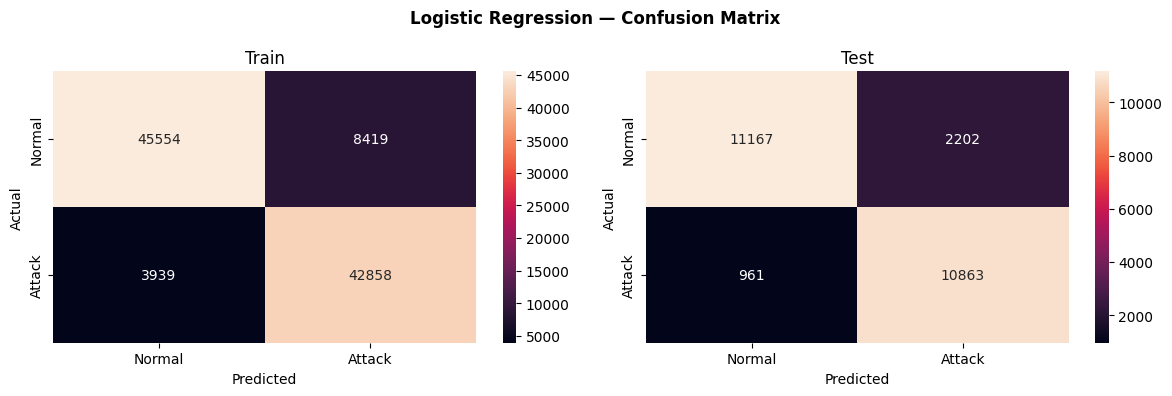

In [18]:
lr = LogisticRegression().fit(x_train, y_train)
evaluate_classification(lr, "Logistic Regression", x_train, x_test, y_train, y_test)

### Gaussian Naive Bayes


  GaussianNB
  Train → Acc:91.99%  Prec:93.13%  Rec:89.35%  F1:91.20%
  Test  → Acc:91.91%  Prec:92.95%  Rec:89.56%  F1:91.22%


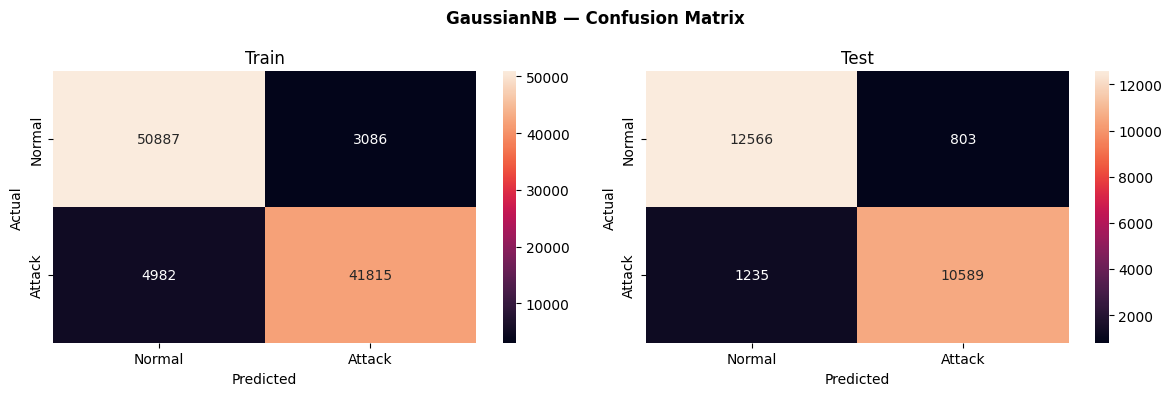

In [19]:
gnb = GaussianNB().fit(x_train, y_train)
evaluate_classification(gnb, "GaussianNB", x_train, x_test, y_train, y_test)

### SVM

In [20]:
lin_svc = svm.LinearSVC().fit(x_train, y_train)


  Linear SVC(LBasedImpl)
  Train → Acc:97.20%  Prec:97.92%  Rec:96.02%  F1:96.96%
  Test  → Acc:97.16%  Prec:97.91%  Rec:96.00%  F1:96.95%


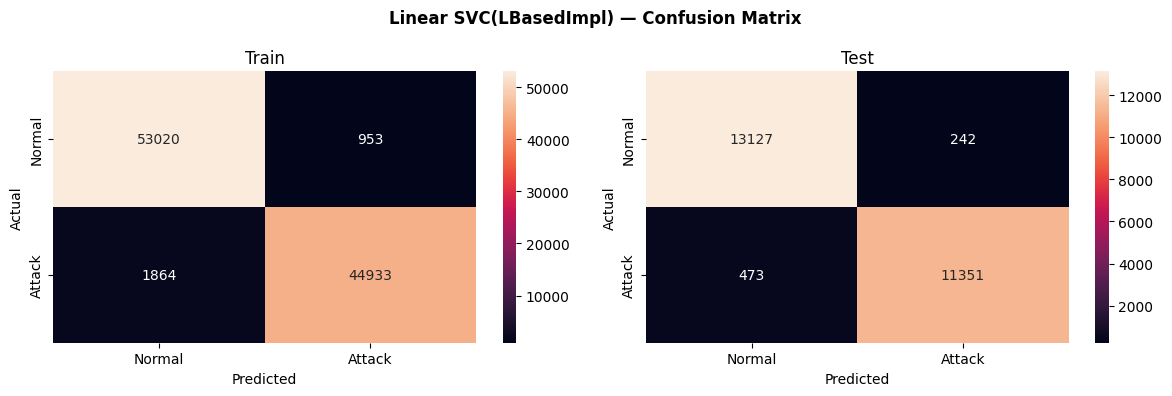

In [21]:
evaluate_classification(lin_svc, "Linear SVC(LBasedImpl)", x_train, x_test, y_train, y_test)

### Decison Tree 


  DecisionTreeClassifier
  Train → Acc:100.00%  Prec:100.00%  Rec:99.99%  F1:100.00%
  Test  → Acc:99.82%  Prec:99.81%  Rec:99.81%  F1:99.81%


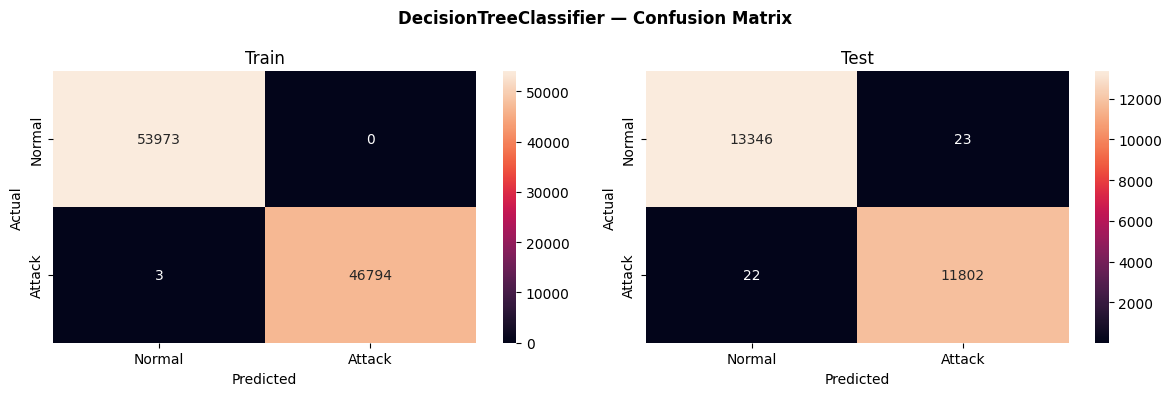

In [22]:
dt = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)
tdt = DecisionTreeClassifier().fit(x_train, y_train)
evaluate_classification(tdt, "DecisionTreeClassifier", x_train, x_test, y_train, y_test)

### features Importance

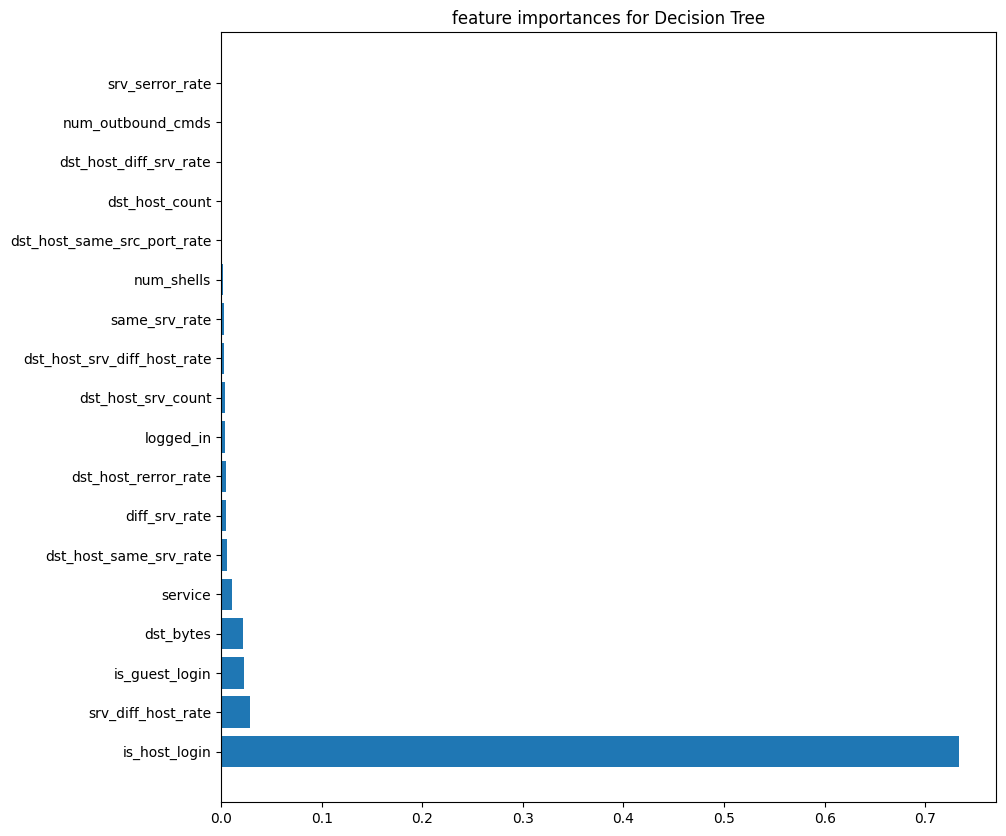

In [23]:
def f_importances(coef, names, top=-1):
    imp = coef
    imp, names = zip(*sorted(list(zip(imp, names))))

    # Show all features
    if top == -1:
        top = len(names)
    
    plt.figure(figsize=(10,10))
    plt.barh(range(top), imp[::-1][0:top], align='center')
    plt.yticks(range(top), names[::-1][0:top])
    plt.title('feature importances for Decision Tree')
    plt.show()

features_names = data_train.drop(['outcome', 'level'] , axis = 1)
f_importances(abs(tdt.feature_importances_), features_names, top=18)

### Random Forest


  RandomForestClassifier
  Train → Acc:100.00%  Prec:100.00%  Rec:100.00%  F1:100.00%
  Test  → Acc:99.85%  Prec:99.92%  Rec:99.75%  F1:99.83%


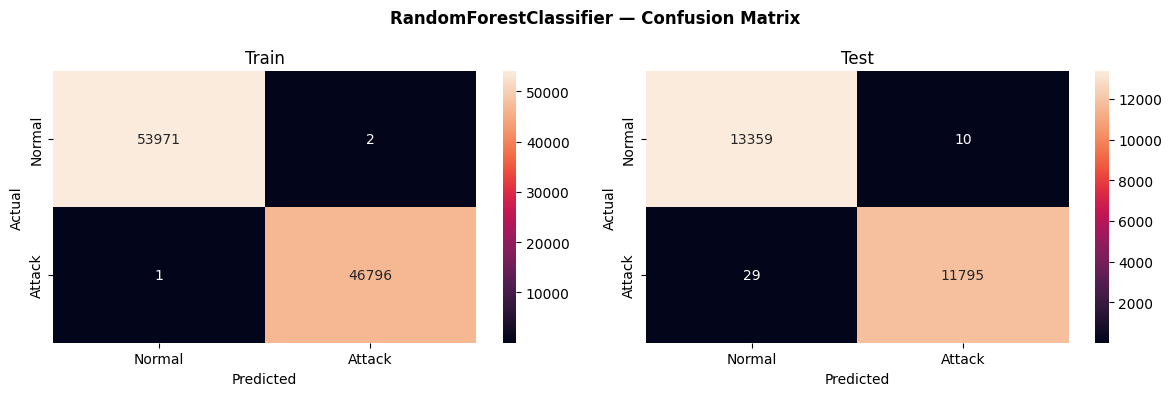

In [24]:
rf = RandomForestClassifier().fit(x_train, y_train)
evaluate_classification(rf, "RandomForestClassifier", x_train, x_test, y_train, y_test)

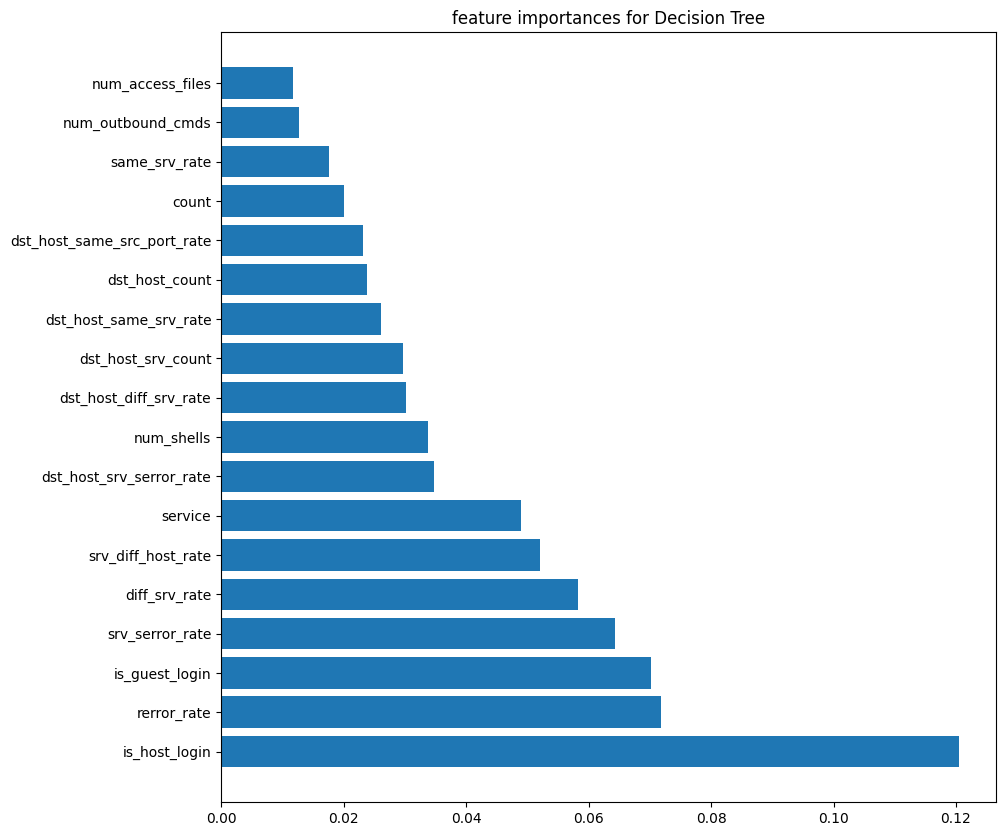

In [25]:
f_importances(abs(rf.feature_importances_), features_names, top=18)

## ***Step 2 — CNN (Conv1D) Model***
> **What changed from the original?**  
> - The original model was a plain **Dense (MLP)** network — not a CNN at all.  
> - A real **Conv1D** CNN extracts **local feature patterns** across the 41 network features, which is far more suited to tabular time-series-like IDS data.  
> - Architecture: `Conv1D → MaxPool → Conv1D → MaxPool → Flatten → Dense → Dropout → Output`

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Derive feature count and reshape for Conv1D (needs 3-D input) ─────────────
n_features = x_train.shape[1]
x_train_dl = x_train.reshape(x_train.shape[0], n_features, 1)
x_test_dl  = x_test.reshape(x_test.shape[0],  n_features, 1)

def build_cnn_model(n_features):
    """
    Real Conv1D CNN for binary intrusion detection.
    Input shape : (n_features, 1)  — 3-D tensor from Step 1 reshape
    Output      : sigmoid → probability of 'attack' (1)
    
    Architecture
    ────────────
    Conv1D(64, k=3) → BN → MaxPool(2)
    Conv1D(128, k=3) → BN → MaxPool(2)
    Conv1D(64, k=3) → BN
    Flatten
    Dense(128) → Dropout(0.4)
    Dense(64)  → Dropout(0.3)
    Dense(1, sigmoid)
    """
    model = Sequential([
        # Block 1 — low-level feature patterns
        Conv1D(filters=64, kernel_size=3, activation='relu',
               padding='same', input_shape=(n_features, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 2 — higher-level patterns
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 3 — condensed feature representation
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),

        # Classifier head
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')     # binary output: 0=normal, 1=attack
    ], name='CNN_Conv1D')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ── Build and inspect ─────────────────────────────────────────────────────────
cnn_model = build_cnn_model(n_features)
cnn_model.summary()


Model: "CNN_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 122, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 122, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,833 (1.16 MB)

 Trainable params: 304,321 (1.16 MB)

 Non-trainable params: 512 (2.00 KB)

## ***Standardize features***

In [27]:
# Standardize features
# NOTE: fit on train only, then transform both — prevents data leakage
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)          # ← was fit_transform (bug fixed)

## ***Step 1 — Reshape Data for Deep Learning Models***
> **Why reshape?**  
> - ML models (RF, SVM, etc.) consume a flat 2-D array: `(samples, features)`  
> - DL models like **Conv1D**, **LSTM**, **GRU** and the **Hybrid** model expect a 3-D array: `(samples, timesteps, channels)`  
> - We treat each feature as one timestep with 1 channel → shape becomes `(samples, n_features, 1)`

In [28]:
# ── Step 1: Reshape flat arrays into 3-D tensors for DL models ───────────────
# ML shape  : (samples, features)        e.g. (101977, 115)
# DL shape  : (samples, features, 1)     e.g. (101977, 115, 1)

n_features = x_train.shape[1]

x_train_dl = x_train.reshape(x_train.shape[0], n_features, 1)
x_test_dl  = x_test.reshape(x_test.shape[0],  n_features, 1)

# ── Confirmation ─────────────────────────────────────────────────────────────
print("=" * 55)
print("        DATA SHAPE VERIFICATION")
print("=" * 55)
print(f"  ML  input  →  x_train : {x_train.shape}")
print(f"  ML  input  →  x_test  : {x_test.shape}")
print("-" * 55)
print(f"  DL  input  →  x_train_dl : {x_train_dl.shape}")
print(f"  DL  input  →  x_test_dl  : {x_test_dl.shape}")
print("=" * 55)
print(f"\n  ✔ DL input_shape to pass into Conv1D / LSTM / GRU:")
print(f"      input_shape = ({n_features}, 1)")
print(f"\n  ✔ Labels shape:")
print(f"      y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"      Classes : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print("=" * 55)

        DATA SHAPE VERIFICATION
  ML  input  →  x_train : (100770, 122)
  ML  input  →  x_test  : (25193, 122)
-------------------------------------------------------
  DL  input  →  x_train_dl : (100770, 122, 1)
  DL  input  →  x_test_dl  : (25193, 122, 1)

  ✔ DL input_shape to pass into Conv1D / LSTM / GRU:
      input_shape = (122, 1)

  ✔ Labels shape:
      y_train : (100770,)  |  y_test : (25193,)
      Classes : {np.int64(0): np.int64(53973), np.int64(1): np.int64(46797)}


### CNN Model — Training
Uses `x_train_dl` (3-D shape) with:
- **EarlyStopping** — stop when `val_loss` stops improving (patience=5), restores best weights  
- **ReduceLROnPlateau** — halves learning rate when validation plateaus (patience=3)

In [29]:
# ── Callbacks ────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# ── Train on 3-D DL input ─────────────────────────────────────────────────────
cnn_history = cnn_model.fit(
    x_train_dl, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - accuracy: 0.9815 - auc: 0.9971 - loss: 0.0552 - precision: 0.9827 - recall: 0.9775 - val_accuracy: 0.9879 - val_auc: 0.9988 - val_loss: 0.0336 - val_precision: 0.9955 - val_recall: 0.9783 - learning_rate: 0.0010
Epoch 2/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9899 - auc: 0.9988 - loss: 0.0297 - precision: 0.9915 - recall: 0.9868 - val_accuracy: 0.9935 - val_auc: 0.9995 - val_loss: 0.0199 - val_precision: 0.9943 - val_recall: 0.9915 - learning_rate: 0.0010
Epoch 3/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 51s 40ms/step - accuracy: 0.9923 - auc: 0.9993 - loss: 0.0219 - precision: 0.9939 - recall: 0.9895 - val_accuracy: 0.9915 - val_auc: 0.9995 - val_loss: 0.0207 - val_precision: 0.9911 - val_recall: 0.9905 - learning_rate: 0.0010
Epoch 4/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9931 - auc: 0.9994 - loss: 0.0199 - precision: 0.9946 - recall: 0.9905 - val_accuracy: 0.9924 - val_auc: 0.9993 - val_lo

### CNN Model — Training Curves

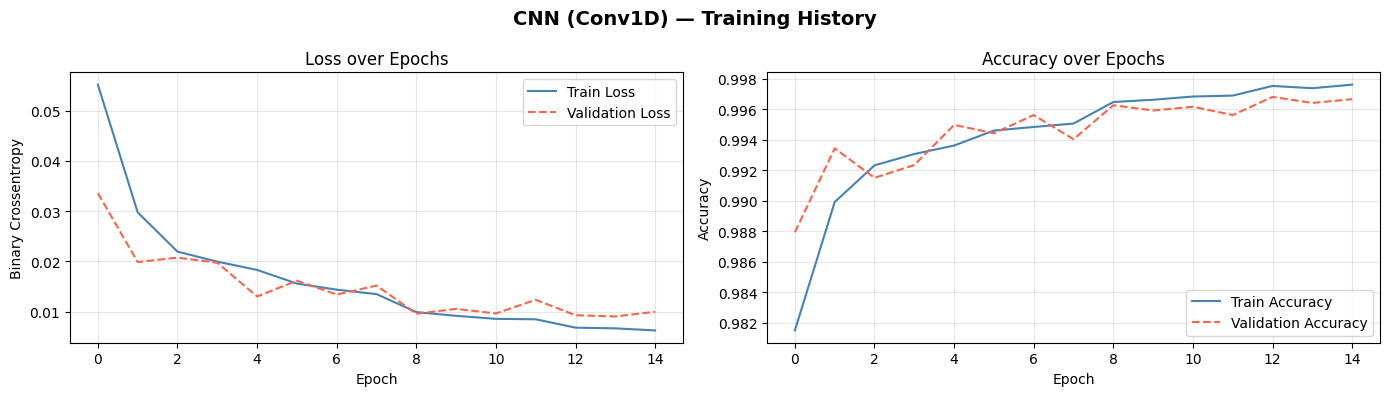

In [30]:
def plot_training_history(history, model_name):
    """Plot loss and accuracy curves for train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # ── Loss ──────────────────────────────────────────────────────────────────
    axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Crossentropy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Accuracy ──────────────────────────────────────────────────────────────
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(cnn_history, 'CNN (Conv1D)')

### CNN Model — Evaluation
Evaluates on both train and test sets. Computes: **Accuracy, Precision, Recall, F1, AUC-ROC**.  
Results are stored in `results_tracker` — this dict will be reused to build the final comparison table across ALL models (CNN, LSTM, GRU, Hybrid).


  CNN (Conv1D) — Results
  Metric            Train       Test
  ----------------------------------
  Accuracy         99.77%     99.63%
  Precision        99.82%     99.75%
  Recall           99.68%     99.47%
  F1-Score         99.75%     99.61%
  AUC-ROC         100.00%     99.99%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13369
      Attack       1.00      0.99      1.00     11824

    accuracy                           1.00     25193
   macro avg       1.00      1.00      1.00     25193
weighted avg       1.00      1.00      1.00     25193



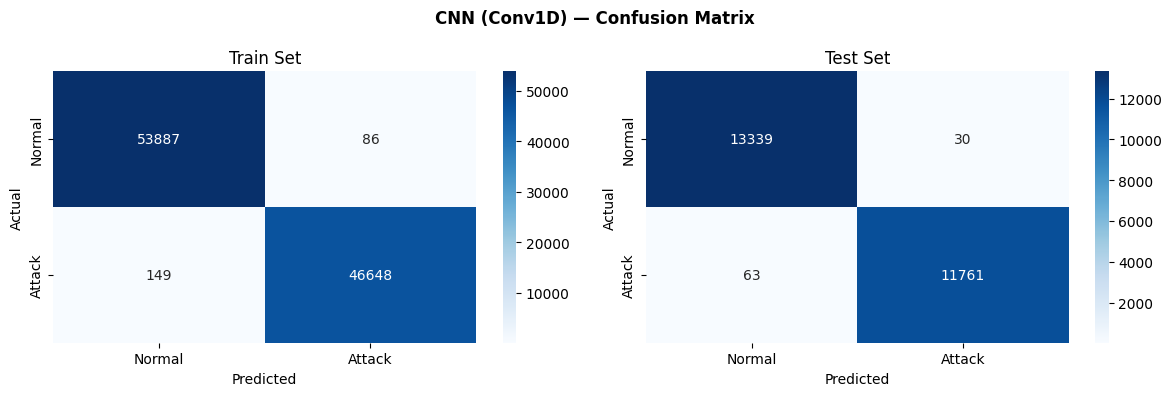

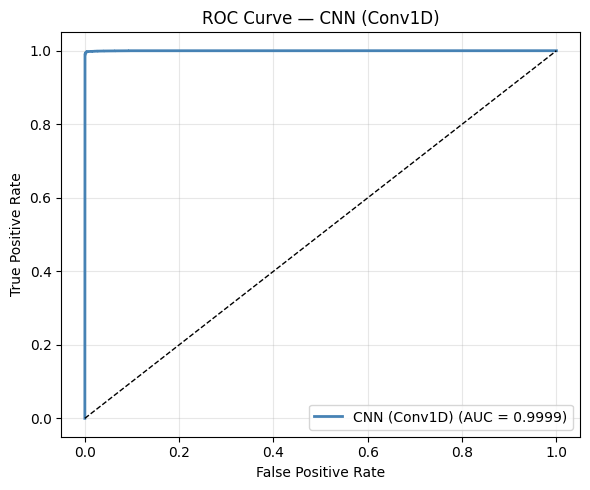

  ✔ Results saved to results_tracker['CNN (Conv1D)']


In [31]:
from sklearn import metrics as sk_metrics

# ── Results tracker — will accumulate metrics for ALL models ─────────────────
# Populated here for CNN, will be extended in Steps 3/4/5 (LSTM, GRU, Hybrid)
results_tracker = {}

# ── Shared evaluation function for ML models (sklearn-style predict) ─────────
def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    """Evaluate sklearn-style classifiers (RF, SVM, DT, etc.)."""
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_acc  = sk_metrics.accuracy_score(y_train, train_pred)
    train_prec = sk_metrics.precision_score(y_train, train_pred, zero_division=0)
    train_rec  = sk_metrics.recall_score(y_train, train_pred, zero_division=0)
    train_f1   = sk_metrics.f1_score(y_train, train_pred, zero_division=0)

    test_acc   = sk_metrics.accuracy_score(y_test, test_pred)
    test_prec  = sk_metrics.precision_score(y_test, test_pred, zero_division=0)
    test_rec   = sk_metrics.recall_score(y_test, test_pred, zero_division=0)
    test_f1    = sk_metrics.f1_score(y_test, test_pred, zero_division=0)

    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f"  Train → Acc:{train_acc*100:.2f}%  Prec:{train_prec*100:.2f}%  Rec:{train_rec*100:.2f}%  F1:{train_f1*100:.2f}%")
    print(f"  Test  → Acc:{test_acc*100:.2f}%  Prec:{test_prec*100:.2f}%  Rec:{test_rec*100:.2f}%  F1:{test_f1*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name} — Confusion Matrix', fontweight='bold')
    for ax, cm, title in zip(axes,
                              [sk_metrics.confusion_matrix(y_train, train_pred),
                               sk_metrics.confusion_matrix(y_test, test_pred)],
                              ['Train', 'Test']):
        sns.heatmap(cm, annot=True, fmt='g', ax=ax,
                    xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
        ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()


# ── DL-specific evaluation function ──────────────────────────────────────────
def evaluate_dl_model(model, name, X_train, X_test, y_train, y_test):
    """
    Evaluate a compiled Keras binary classifier.
    - Accepts 3-D DL inputs  (samples, features, 1)
    - Computes Accuracy, Precision, Recall, F1, AUC-ROC
    - Plots confusion matrices + ROC curve
    - Stores results in global results_tracker dict
    """
    # ── Predictions ───────────────────────────────────────────────────────────
    train_prob = model.predict(X_train, verbose=0).ravel()
    test_prob  = model.predict(X_test,  verbose=0).ravel()
    train_pred = (train_prob > 0.5).astype(int)
    test_pred  = (test_prob  > 0.5).astype(int)

    # ── Metrics ───────────────────────────────────────────────────────────────
    train_acc  = sk_metrics.accuracy_score(y_train, train_pred)
    train_prec = sk_metrics.precision_score(y_train, train_pred, zero_division=0)
    train_rec  = sk_metrics.recall_score(y_train, train_pred, zero_division=0)
    train_f1   = sk_metrics.f1_score(y_train, train_pred, zero_division=0)
    train_auc  = sk_metrics.roc_auc_score(y_train, train_prob)

    test_acc   = sk_metrics.accuracy_score(y_test, test_pred)
    test_prec  = sk_metrics.precision_score(y_test, test_pred, zero_division=0)
    test_rec   = sk_metrics.recall_score(y_test, test_pred, zero_division=0)
    test_f1    = sk_metrics.f1_score(y_test, test_pred, zero_division=0)
    test_auc   = sk_metrics.roc_auc_score(y_test, test_prob)

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"\n{'='*60}\n  {name} — Results\n{'='*60}")
    print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*34}")
    for metric, tr, te in [('Accuracy',  train_acc,  test_acc),
                             ('Precision', train_prec, test_prec),
                             ('Recall',    train_rec,  test_rec),
                             ('F1-Score',  train_f1,   test_f1),
                             ('AUC-ROC',   train_auc,  test_auc)]:
        print(f"  {metric:<12} {tr*100:>9.2f}% {te*100:>9.2f}%")
    print(f"{'='*60}")
    print(sk_metrics.classification_report(y_test, test_pred,
          target_names=['Normal', 'Attack']))

    # ── Confusion matrices ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name} — Confusion Matrix', fontweight='bold')
    for ax, cm, title in zip(axes,
                              [sk_metrics.confusion_matrix(y_train, train_pred),
                               sk_metrics.confusion_matrix(y_test,  test_pred)],
                              ['Train', 'Test']):
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=ax,
                    xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
        ax.set_title(f'{title} Set'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = sk_metrics.roc_curve(y_test, test_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2,
             label=f'{name} (AUC = {test_auc:.4f})')
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # ── Store in tracker ──────────────────────────────────────────────────────
    results_tracker[name] = {
        'Accuracy' : round(test_acc  * 100, 2),
        'Precision': round(test_prec * 100, 2),
        'Recall'   : round(test_rec  * 100, 2),
        'F1-Score' : round(test_f1   * 100, 2),
        'AUC-ROC'  : round(test_auc  * 100, 2),
    }
    print(f"  ✔ Results saved to results_tracker['{name}']")
    return results_tracker[name]


# ── Evaluate CNN ──────────────────────────────────────────────────────────────
cnn_results = evaluate_dl_model(cnn_model, 'CNN (Conv1D)',
                                 x_train_dl, x_test_dl,
                                 y_train, y_test)

## ***Optimisation Using RandomizedSearchCV***

In [32]:
# ── Install scikeras if needed ─────────────────────────────────────────────
# tensorflow.keras.wrappers.scikit_learn.KerasClassifier was removed in TF 2.12
# The modern replacement is: pip install scikeras
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikeras', '-q'])

from scikeras.wrappers import KerasClassifier as SciKerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# ── Build function compatible with scikeras ────────────────────────────────
def build_cnn_for_search(filters1=64, filters2=128, dense_units=128,
                          dropout_rate=0.4, learning_rate=0.001):
    """
    Parameterised Conv1D model used by RandomizedSearchCV.
    scikeras passes hyperparams directly as kwargs to this function.
    """
    model = Sequential([
        Conv1D(filters=filters1, kernel_size=3, activation='relu',
               padding='same', input_shape=(n_features, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=filters2, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Wrap with SciKeras ────────────────────────────────────────────────────
cnn_tunable = SciKerasClassifier(
    model=build_cnn_for_search,
    epochs=10,
    batch_size=64,
    verbose=0
)

# ── Hyperparameter search space ───────────────────────────────────────────
param_grid = {
    'model__filters1'    : [32, 64, 128],
    'model__filters2'    : [64, 128, 256],
    'model__dense_units' : [64, 128, 256],
    'model__dropout_rate': [0.2, 0.3, 0.4],
    'model__learning_rate': [0.01, 0.001, 0.0001],
    'batch_size'         : [32, 64],
    'epochs'             : [10, 20],
}

# ── RandomizedSearchCV (n_iter=5 keeps runtime reasonable) ───────────────
random_search = RandomizedSearchCV(
    estimator=cnn_tunable,
    param_distributions=param_grid,
    n_iter=5,          # increase to 10-20 for more thorough search
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    random_state=42,
    verbose=1
)

print("Starting RandomizedSearchCV for CNN hyperparameter tuning...")
print("(Uses x_train_dl — 3-D input for Conv1D)")
random_search_results = random_search.fit(x_train_dl, y_train)

print(f"\nBest CV Accuracy : {random_search_results.best_score_*100:.2f}%")
print(f"Best Parameters  : {random_search_results.best_params_}")

Starting RandomizedSearchCV for CNN hyperparameter tuning...
(Uses x_train_dl — 3-D input for Conv1D)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best CV Accuracy : 99.61%
Best Parameters  : {'model__learning_rate': 0.0001, 'model__filters2': 128, 'model__filters1': 128, 'model__dropout_rate': 0.3, 'model__dense_units': 128, 'epochs': 20, 'batch_size': 64}


---
## ***Step 3 — LSTM Model***
> **Why LSTM for IDS?**  
> - LSTM (Long Short-Term Memory) is a Recurrent Neural Network variant designed to learn **long-range sequential dependencies**.  
> - Network traffic features carry temporal correlations — e.g. a DoS attack involves many packets with similar patterns in sequence. LSTM captures this.  
> - Unlike the CNN (which extracts **local spatial patterns**), LSTM tracks **what happened across the entire feature sequence** using its cell state (memory gates: input, forget, output).  
>  
> Architecture: `LSTM(128, return_sequences=True) → Dropout → LSTM(64) → Dropout → Dense(64) → Dropout → Dense(1, sigmoid)`

In [33]:
from tensorflow.keras.layers import LSTM

def build_lstm_model(n_features):
    """
    Stacked Bidirectional-ready LSTM for binary intrusion detection.
    Input shape : (n_features, 1)  — same 3-D tensor used by CNN
    Output      : sigmoid → probability of 'attack' (1)

    Architecture
    ────────────
    LSTM(128, return_sequences=True) → Dropout(0.3)
    LSTM(64,  return_sequences=False) → Dropout(0.3)
    Dense(64, relu) → Dropout(0.2)
    Dense(1, sigmoid)

    Notes
    ─────
    • return_sequences=True  on the first LSTM outputs a sequence so the
      second LSTM can process it further (stacked LSTM).
    • return_sequences=False on the second LSTM collapses the sequence
      into a single context vector for the Dense head.
    • BatchNormalization after each LSTM stabilises gradient flow.
    """
    model = Sequential([
        LSTM(128, return_sequences=True,
             input_shape=(n_features, 1),
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')    # binary output: 0=normal, 1=attack
    ], name='LSTM_Stacked')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ── Build and inspect ─────────────────────────────────────────────────────────
lstm_model = build_lstm_model(n_features)
lstm_model.summary()

Model: "LSTM_Stacked"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 122, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 122, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,961 (472.50 KB)

 Trainable params: 120,577 (471.00 KB)

 Non-trainable params: 384 (1.50 KB)

### LSTM Model — Training
Same callbacks as CNN: **EarlyStopping** (patience=5) + **ReduceLROnPlateau** (patience=3).  
Input: `x_train_dl` shape `(samples, n_features, 1)` — same 3-D tensor.

In [34]:
# ── Callbacks (same strategy as CNN) ─────────────────────────────────────────
lstm_early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
lstm_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────────────
lstm_history = lstm_model.fit(
    x_train_dl, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[lstm_early_stop, lstm_reduce_lr],
    verbose=1
)

Epoch 1/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2845s 2s/step - accuracy: 0.9392 - auc: 0.9756 - loss: 0.1988 - precision: 0.9423 - recall: 0.9258 - val_accuracy: 0.8844 - val_auc: 0.8333 - val_loss: 0.5465 - val_precision: 0.9307 - val_recall: 0.8098 - learning_rate: 0.0010
Epoch 2/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 518s 411ms/step - accuracy: 0.9607 - auc: 0.9882 - loss: 0.1355 - precision: 0.9614 - recall: 0.9538 - val_accuracy: 0.9676 - val_auc: 0.9941 - val_loss: 0.1091 - val_precision: 0.9709 - val_recall: 0.9586 - learning_rate: 0.0010
Epoch 3/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 851s 676ms/step - accuracy: 0.9610 - auc: 0.9874 - loss: 0.1358 - precision: 0.9624 - recall: 0.9534 - val_accuracy: 0.6153 - val_auc: 0.8841 - val_loss: 1.0453 - val_precision: 0.5524 - val_recall: 0.8754 - learning_rate: 0.0010
Epoch 4/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 597s 474ms/step - accuracy: 0.9663 - auc: 0.9860 - loss: 0.1280 - precision: 0.9717 - recall: 0.9554 - val_accuracy: 0.9628 - val_auc: 0.9885 - 

### LSTM Model — Training Curves

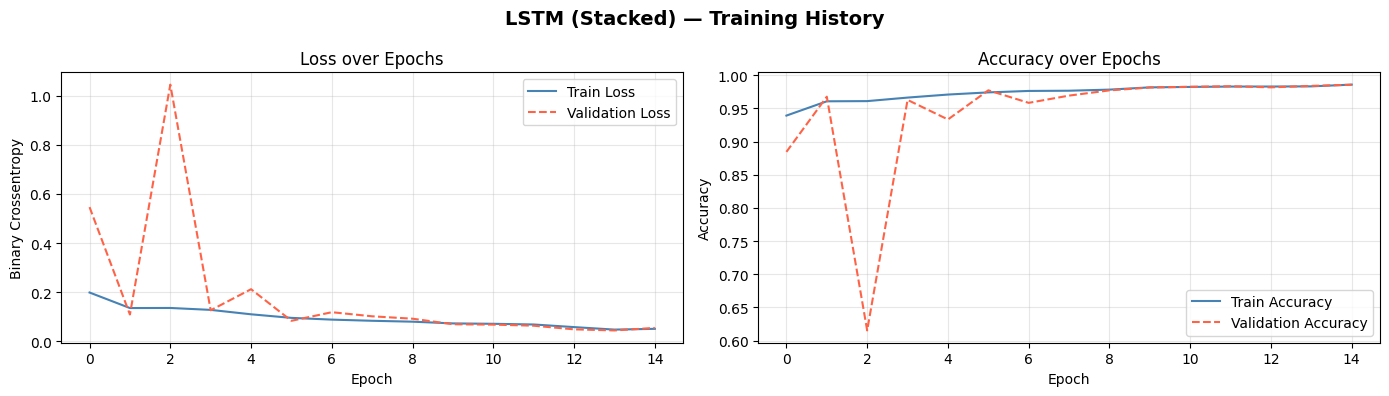

In [35]:
# Reuses the plot_training_history() function defined in Step 2
plot_training_history(lstm_history, 'LSTM (Stacked)')

### LSTM Model — Evaluation
Computes Accuracy, Precision, Recall, F1, AUC-ROC. Plots confusion matrices + ROC curve.  
Results automatically stored in `results_tracker['LSTM (Stacked)']` for the final comparison table.


  LSTM (Stacked) — Results
  Metric            Train       Test
  ----------------------------------
  Accuracy         98.45%     98.25%
  Precision        99.03%     98.87%
  Recall           97.62%     97.40%
  F1-Score         98.32%     98.13%
  AUC-ROC          99.88%     99.88%
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98     13369
      Attack       0.99      0.97      0.98     11824

    accuracy                           0.98     25193
   macro avg       0.98      0.98      0.98     25193
weighted avg       0.98      0.98      0.98     25193



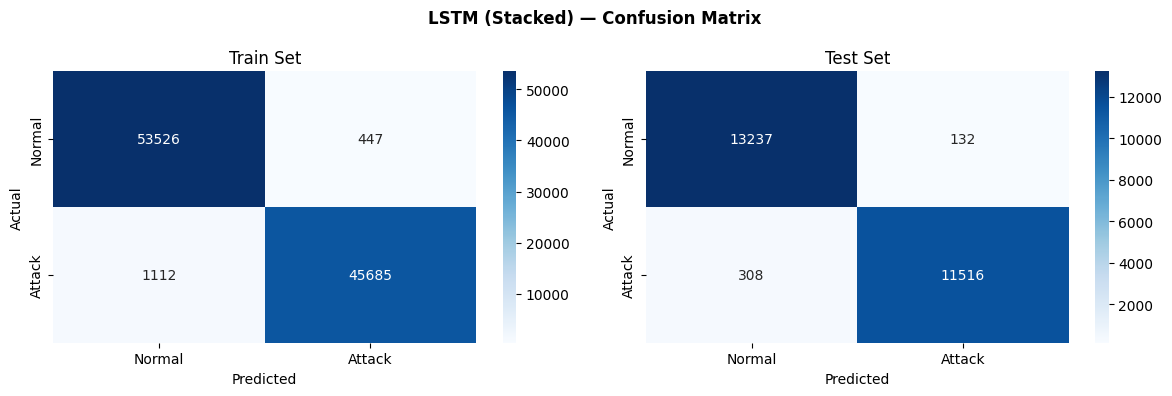

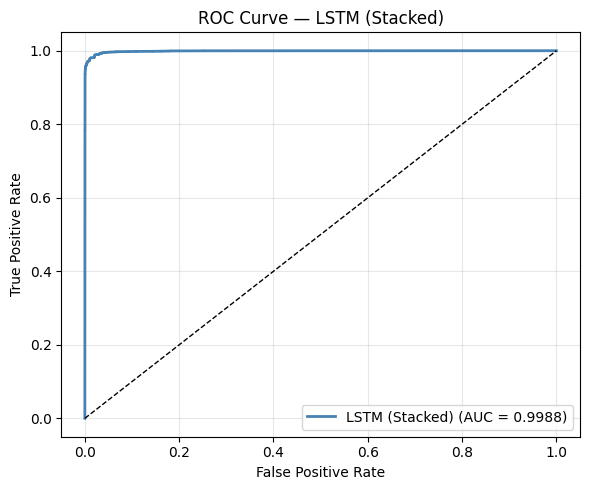

  ✔ Results saved to results_tracker['LSTM (Stacked)']

📊 Results so far:
  Model                  Accuracy  Precision     Recall   F1-Score    AUC-ROC
  ------------------------------------------------------------------------
  CNN (Conv1D)             99.63%     99.75%     99.47%     99.61%     99.99%
  LSTM (Stacked)           98.25%     98.87%     97.40%     98.13%     99.88%


In [36]:
# Reuses evaluate_dl_model() from Step 2 — handles 3-D input, plots CM + ROC, saves to results_tracker
lstm_results = evaluate_dl_model(lstm_model, 'LSTM (Stacked)',
                                  x_train_dl, x_test_dl,
                                  y_train, y_test)

# ── Quick side-by-side snapshot: CNN vs LSTM so far ──────────────────────────
print("\n📊 Results so far:")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*72}")
for model_name, res in results_tracker.items():
    print(f"  {model_name:<20} {res['Accuracy']:>9.2f}% {res['Precision']:>9.2f}% "
          f"{res['Recall']:>9.2f}% {res['F1-Score']:>9.2f}% {res['AUC-ROC']:>9.2f}%")

---
## ***Step 4 — GRU Model***
> **Why GRU for IDS?**  
> - GRU (Gated Recurrent Unit) is a streamlined variant of LSTM with **fewer parameters** — it merges the forget and input gates into a single **update gate** and has no separate cell state.  
> - Trains **faster** than LSTM while achieving comparable accuracy on many sequence tasks.  
> - Serves as an important individual baseline before they are both fused into the Hybrid model (Step 5).  
>  
> | | LSTM | GRU |
> |---|---|---|
> | Gates | 3 (input, forget, output) | 2 (update, reset) |
> | Cell state | Separate hidden + cell | Single hidden state |
> | Parameters | More | Fewer (~25% less) |
> | Speed | Slower | Faster |
>  
> Architecture: `GRU(128, return_sequences=True) → Dropout → GRU(64) → Dropout → Dense(64) → Dropout → Dense(1, sigmoid)`

In [37]:
from tensorflow.keras.layers import GRU

def build_gru_model(n_features):
    """
    Stacked GRU for binary intrusion detection.
    Input shape : (n_features, 1)  — same 3-D tensor used by CNN and LSTM
    Output      : sigmoid → probability of 'attack' (1)

    Architecture
    ────────────
    GRU(128, return_sequences=True) → BatchNorm → Dropout(0.3)
    GRU(64,  return_sequences=False) → BatchNorm → Dropout(0.3)
    Dense(64, relu) → Dropout(0.2)
    Dense(1, sigmoid)

    Key difference from LSTM
    ────────────────────────
    GRU uses an update gate (decides how much past info to keep) and a
    reset gate (decides how much past info to forget) — no separate cell
    state. This makes it ~25% lighter than the equivalent LSTM while
    still capturing long-range dependencies.
    """
    model = Sequential([
        GRU(128, return_sequences=True,
            input_shape=(n_features, 1),
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        GRU(64, return_sequences=False,
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')    # binary output: 0=normal, 1=attack
    ], name='GRU_Stacked')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ── Build and inspect ─────────────────────────────────────────────────────────
gru_model = build_gru_model(n_features)
gru_model.summary()

Model: "GRU_Stacked"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 122, 128)       │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 122, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,545 (361.50 KB)

 Trainable params: 92,161 (360.00 KB)

 Non-trainable params: 384 (1.50 KB)

### GRU Model — Training
Same callbacks as CNN and LSTM: **EarlyStopping** (patience=5) + **ReduceLROnPlateau** (patience=3).  
Input: `x_train_dl` — 3-D tensor `(samples, n_features, 1)`.

DL input shape: (100770, 122, 1)  |  n_features=122

⏳ Retraining CNN …

  CNN (Conv1D) — Results
  Accuracy     Train:  99.74%  Test:  99.61%
  Precision    Train:  99.85%  Test:  99.75%
  Recall       Train:  99.60%  Test:  99.41%
  F1-Score     Train:  99.72%  Test:  99.58%
  AUC-ROC      Train:  99.99%  Test:  99.99%


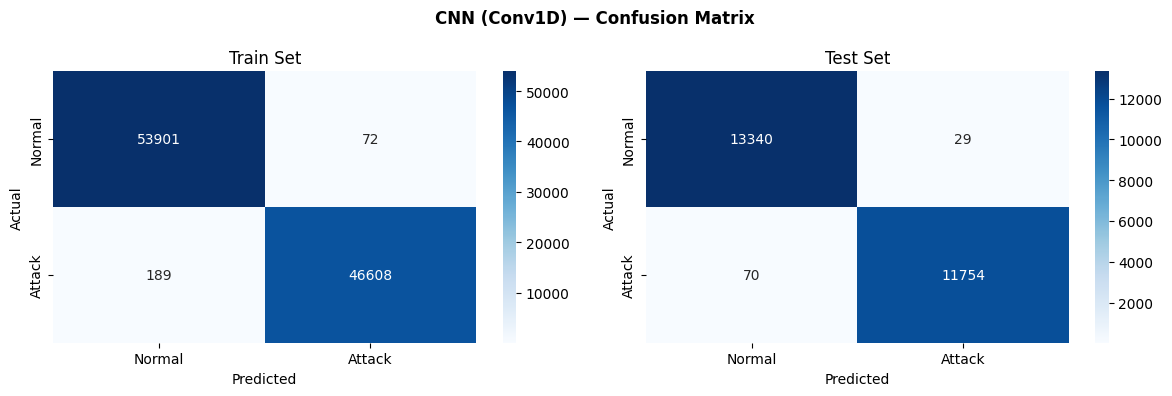

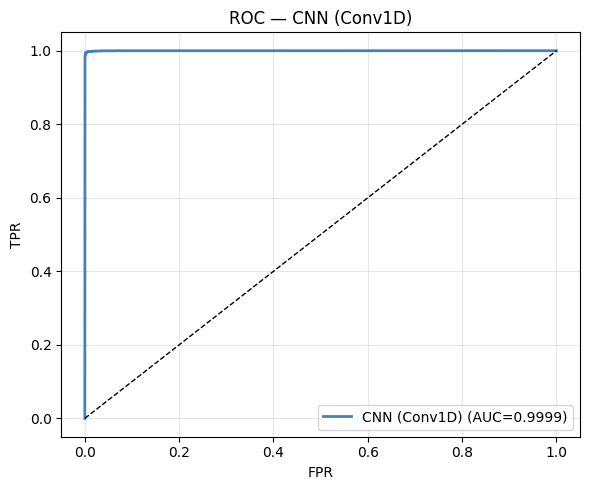

  ✔ Saved → results_tracker['CNN (Conv1D)']

⏳ Retraining LSTM …

  LSTM (Stacked) — Results
  Accuracy     Train:  98.31%  Test:  98.12%
  Precision    Train:  98.04%  Test:  97.79%
  Recall       Train:  98.34%  Test:  98.22%
  F1-Score     Train:  98.19%  Test:  98.00%
  AUC-ROC      Train:  99.87%  Test:  99.83%


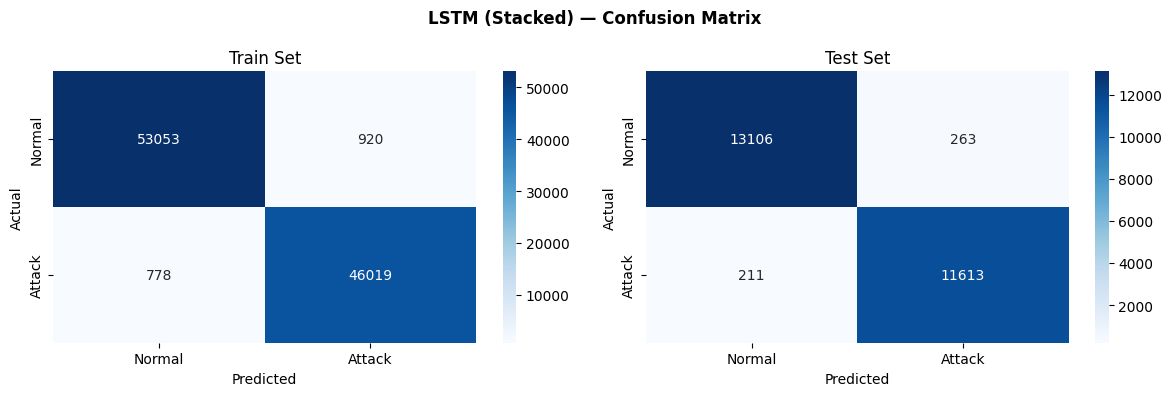

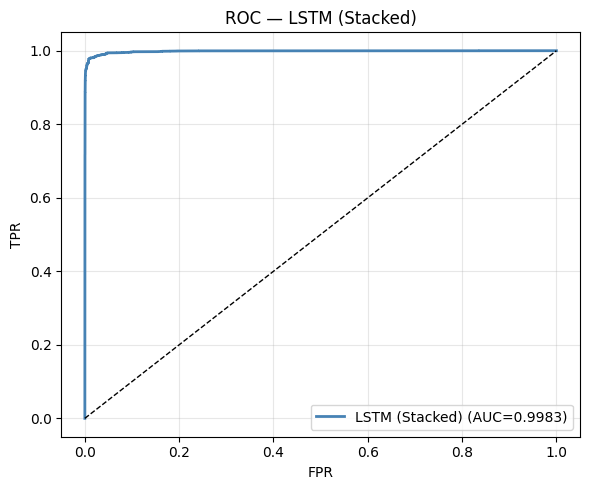

  ✔ Saved → results_tracker['LSTM (Stacked)']

✅ State restored! Variables ready: x_train_dl, x_test_dl, n_features,
   cnn_model, lstm_model, gru_model, results_tracker, plot_training_history, evaluate_dl_model
   results_tracker keys so far: ['CNN (Conv1D)', 'LSTM (Stacked)']


In [1]:

# ══════════════════════════════════════════════════════════════════════════════
# ⚡ RESTORE STATE CELL — Run this single cell to rebuild all variables needed
#    for GRU (and beyond) without re-running slow ML model training cells.
#    Skips: RF, SVM, KNN, XGBoost, DecisionTree, RandomizedSearchCV
#    Includes: data loading, preprocessing, CNN train, LSTM train, GRU build
# ══════════════════════════════════════════════════════════════════════════════
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization,
                                     LSTM, GRU)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn import metrics as sk_metrics
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Load & column-name data ───────────────────────────────────────────────────
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes',
            'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
            'num_compromised','root_shell','su_attempted','num_root',
            'num_file_creations','num_shells','num_access_files',
            'num_outbound_cmds','is_host_login','is_guest_login','count',
            'srv_count','serror_rate','srv_serror_rate','rerror_rate',
            'srv_rerror_rate','same_srv_rate','diff_srv_rate',
            'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
            'dst_host_same_srv_rate','dst_host_diff_srv_rate',
            'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
            'dst_host_serror_rate','dst_host_srv_serror_rate',
            'dst_host_rerror_rate','dst_host_srv_rerror_rate',
            'outcome','level'])
data_train = pd.read_csv("nsl-kdd/KDDTrain+.txt")
data_train.columns = columns

# binary outcome
data_train.loc[data_train['outcome'] == "normal", "outcome"] = 'normal'
data_train.loc[data_train['outcome'] != 'normal', "outcome"] = 'attack'

# ── Preprocessing ─────────────────────────────────────────────────────────────
cat_cols = ['is_host_login','protocol_type','service','flag','land',
            'logged_in','is_guest_login','level','outcome']

def Scaling(df_num, cols):
    std_scaler = RobustScaler()
    return pd.DataFrame(std_scaler.fit_transform(df_num), columns=cols)

def preprocess(dataframe):
    df_num   = dataframe.drop(cat_cols, axis=1)
    num_cols = df_num.columns
    scaled_df = Scaling(df_num, num_cols)
    dataframe.drop(labels=num_cols, axis="columns", inplace=True)
    dataframe[num_cols] = scaled_df[num_cols]
    dataframe.dropna(inplace=True)
    dataframe.drop_duplicates(inplace=True)
    dataframe.loc[dataframe['outcome'] == "normal", "outcome"] = 0
    dataframe.loc[dataframe['outcome'] != 0,        "outcome"] = 1
    dataframe = pd.get_dummies(dataframe, columns=['protocol_type','service','flag'])
    return dataframe

scaled_train = preprocess(data_train)

# ── Features / labels / PCA / split ──────────────────────────────────────────
x = scaled_train.drop(['outcome','level'], axis=1).values
y = scaled_train['outcome'].values.astype('int')

pca_20 = PCA(n_components=20).fit(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# ── Scale + DL reshape ────────────────────────────────────────────────────────
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

n_features   = x_train.shape[1]
x_train_dl   = x_train.reshape(x_train.shape[0], n_features, 1)
x_test_dl    = x_test.reshape(x_test.shape[0],   n_features, 1)
print(f"DL input shape: {x_train_dl.shape}  |  n_features={n_features}")

# ── Helper functions ──────────────────────────────────────────────────────────
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='tomato', linestyle='--')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train Acc',  color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',    color='tomato', linestyle='--')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

results_tracker = {}

def evaluate_dl_model(model, name, X_train, X_test, y_train, y_test):
    train_prob = model.predict(X_train, verbose=0).ravel()
    test_prob  = model.predict(X_test,  verbose=0).ravel()
    train_pred = (train_prob > 0.5).astype(int)
    test_pred  = (test_prob  > 0.5).astype(int)
    test_acc   = sk_metrics.accuracy_score(y_test,  test_pred)
    test_prec  = sk_metrics.precision_score(y_test, test_pred, zero_division=0)
    test_rec   = sk_metrics.recall_score(y_test,    test_pred, zero_division=0)
    test_f1    = sk_metrics.f1_score(y_test,        test_pred, zero_division=0)
    test_auc   = sk_metrics.roc_auc_score(y_test,   test_prob)
    train_acc  = sk_metrics.accuracy_score(y_train,  (train_prob>0.5).astype(int))
    train_prec = sk_metrics.precision_score(y_train, (train_prob>0.5).astype(int), zero_division=0)
    train_rec  = sk_metrics.recall_score(y_train,    (train_prob>0.5).astype(int), zero_division=0)
    train_f1   = sk_metrics.f1_score(y_train,        (train_prob>0.5).astype(int), zero_division=0)
    train_auc  = sk_metrics.roc_auc_score(y_train,   train_prob)
    print(f"\n{'='*60}\n  {name} — Results\n{'='*60}")
    for metric, tr, te in [('Accuracy',train_acc,test_acc),('Precision',train_prec,test_prec),
                             ('Recall',train_rec,test_rec),('F1-Score',train_f1,test_f1),('AUC-ROC',train_auc,test_auc)]:
        print(f"  {metric:<12} Train:{tr*100:>7.2f}%  Test:{te*100:>7.2f}%")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name} — Confusion Matrix', fontweight='bold')
    for ax, cm, title in zip(axes,
                              [sk_metrics.confusion_matrix(y_train, train_pred),
                               sk_metrics.confusion_matrix(y_test,  test_pred)],
                              ['Train','Test']):
        sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=ax,
                    xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
        ax.set_title(f'{title} Set'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    fpr, tpr, _ = sk_metrics.roc_curve(y_test, test_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'{name} (AUC={test_auc:.4f})')
    plt.plot([0,1],[0,1],'k--',lw=1); plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'ROC — {name}'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    results_tracker[name] = {'Accuracy':round(test_acc*100,2),'Precision':round(test_prec*100,2),
                              'Recall':round(test_rec*100,2),'F1-Score':round(test_f1*100,2),'AUC-ROC':round(test_auc*100,2)}
    print(f"  ✔ Saved → results_tracker['{name}']")
    return results_tracker[name]

# ── CNN — build & train (needed for cnn_model + results_tracker) ──────────────
def build_cnn_model(n_features):
    model = Sequential([
        Conv1D(64, 3, activation='relu', padding='same', input_shape=(n_features,1)),
        BatchNormalization(), MaxPooling1D(2),
        Conv1D(128, 3, activation='relu', padding='same'), BatchNormalization(), MaxPooling1D(2),
        Conv1D(64,  3, activation='relu', padding='same'), BatchNormalization(),
        Flatten(), Dense(128, activation='relu'), Dropout(0.4),
        Dense(64, activation='relu'),  Dropout(0.3), Dense(1, activation='sigmoid')
    ], name='CNN_Conv1D')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

cnn_model = build_cnn_model(n_features)
print("\n⏳ Retraining CNN …")
cnn_history = cnn_model.fit(x_train_dl, y_train, validation_split=0.2, epochs=15,
    batch_size=64, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)], verbose=0)
cnn_results = evaluate_dl_model(cnn_model, 'CNN (Conv1D)', x_train_dl, x_test_dl, y_train, y_test)

# ── LSTM — build & train (needed for lstm_model + results_tracker) ────────────
def build_lstm_model(n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(n_features,1), kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), Dropout(0.3),
        LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), Dropout(0.2), Dense(1, activation='sigmoid')
    ], name='LSTM_Stacked')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

lstm_model = build_lstm_model(n_features)
print("\n⏳ Retraining LSTM …")
lstm_history = lstm_model.fit(x_train_dl, y_train, validation_split=0.2, epochs=15,
    batch_size=64, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)], verbose=0)
lstm_results = evaluate_dl_model(lstm_model, 'LSTM (Stacked)', x_train_dl, x_test_dl, y_train, y_test)

# ── GRU — build (training cell is next) ──────────────────────────────────────
def build_gru_model(n_features):
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=(n_features,1), kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), Dropout(0.3),
        GRU(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), Dropout(0.2), Dense(1, activation='sigmoid')
    ], name='GRU_Stacked')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

gru_model = build_gru_model(n_features)
print("\n✅ State restored! Variables ready: x_train_dl, x_test_dl, n_features,")
print("   cnn_model, lstm_model, gru_model, results_tracker, plot_training_history, evaluate_dl_model")
print(f"   results_tracker keys so far: {list(results_tracker.keys())}")


In [2]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
gru_early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
gru_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────────────
gru_history = gru_model.fit(
    x_train_dl, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[gru_early_stop, gru_reduce_lr],
    verbose=1
)

Epoch 1/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 455s 353ms/step - accuracy: 0.8790 - auc: 0.8938 - loss: 0.3548 - precision: 0.9311 - recall: 0.7990 - val_accuracy: 0.8844 - val_auc: 0.8988 - val_loss: 0.4739 - val_precision: 0.9307 - val_recall: 0.8098 - learning_rate: 0.0010
Epoch 2/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 426s 338ms/step - accuracy: 0.9485 - auc: 0.9787 - loss: 0.1692 - precision: 0.9403 - recall: 0.9496 - val_accuracy: 0.9471 - val_auc: 0.9859 - val_loss: 0.1611 - val_precision: 0.9826 - val_recall: 0.9012 - learning_rate: 0.0010
Epoch 3/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 422s 335ms/step - accuracy: 0.9644 - auc: 0.9890 - loss: 0.1207 - precision: 0.9654 - recall: 0.9578 - val_accuracy: 0.8976 - val_auc: 0.9743 - val_loss: 0.2239 - val_precision: 0.9284 - val_recall: 0.8430 - learning_rate: 0.0010
Epoch 4/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 436s 345ms/step - accuracy: 0.9770 - auc: 0.9965 - loss: 0.0730 - precision: 0.9786 - recall: 0.9717 - val_accuracy: 0.9871 - val_auc: 0.9983 

### GRU Model — Training Curves

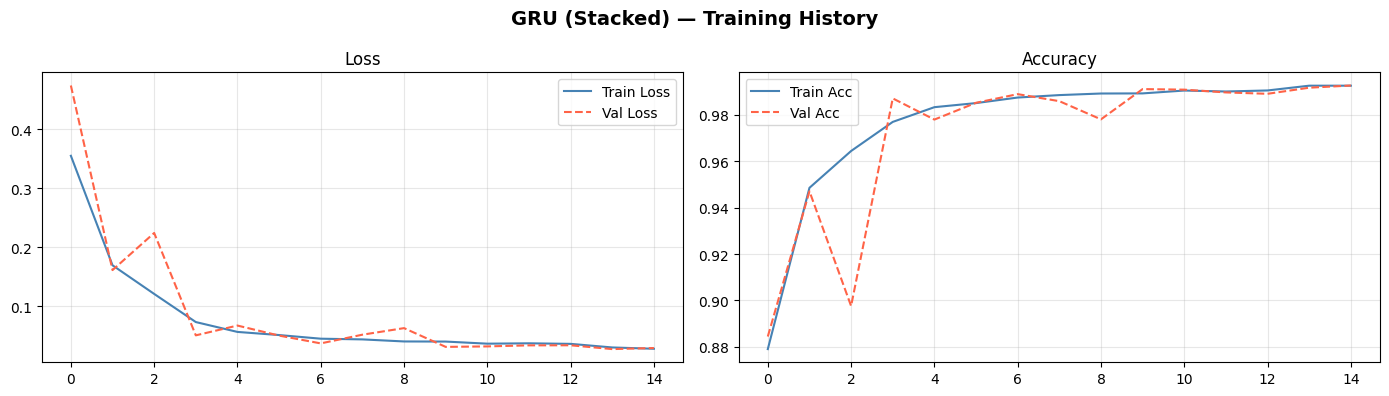

In [5]:
# Reuses plot_training_history() from Step 2
plot_training_history(gru_history, 'GRU (Stacked)')

### GRU Model — Evaluation
Computes Accuracy, Precision, Recall, F1, AUC-ROC. Plots confusion matrices + ROC curve.  
Results stored in `results_tracker['GRU (Stacked)']` for the final comparison table.


  GRU (Stacked) — Results
  Accuracy     Train:  99.29%  Test:  99.16%
  Precision    Train:  99.49%  Test:  99.36%
  Recall       Train:  98.98%  Test:  98.85%
  F1-Score     Train:  99.23%  Test:  99.11%
  AUC-ROC      Train:  99.97%  Test:  99.94%


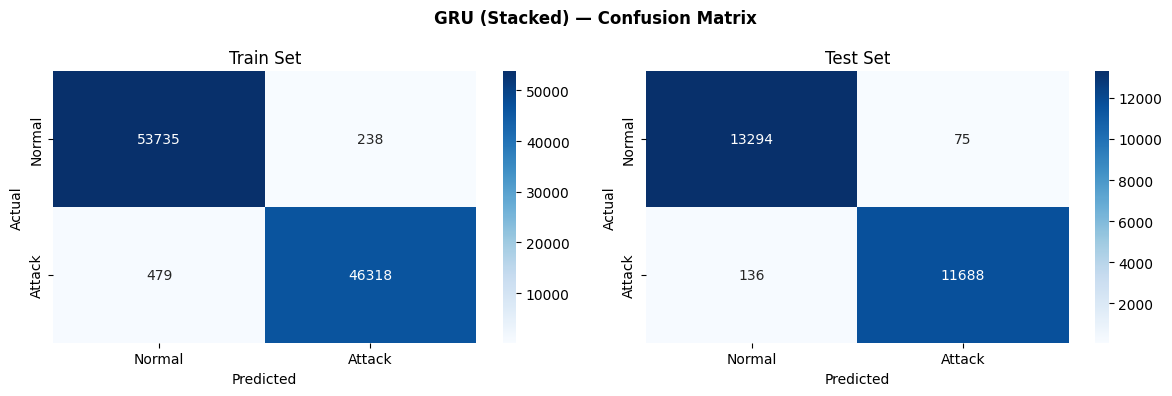

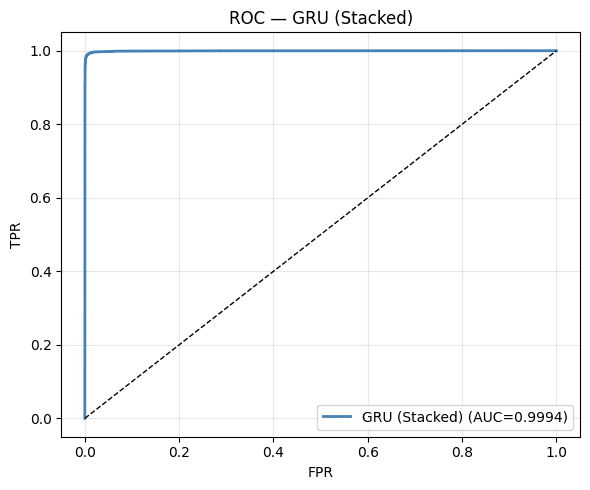

  ✔ Saved → results_tracker['GRU (Stacked)']

📊 Results so far (CNN → LSTM → GRU):
  Model                  Accuracy  Precision     Recall   F1-Score    AUC-ROC
  ------------------------------------------------------------------------
  CNN (Conv1D)             99.61%     99.75%     99.41%     99.58%     99.99%
  LSTM (Stacked)           98.12%     97.79%     98.22%     98.00%     99.83%
  GRU (Stacked)            99.16%     99.36%     98.85%     99.11%     99.94%

⚙️  Model parameter counts (complexity):
  CNN (Conv1D)          Total params:  304,833  |  Trainable:  304,321
  LSTM (Stacked)        Total params:  120,961  |  Trainable:  120,577
  GRU (Stacked)         Total params:   92,545  |  Trainable:   92,161


In [6]:
# Reuses evaluate_dl_model() from Step 2 — CM + ROC + metrics table + saves to results_tracker
gru_results = evaluate_dl_model(gru_model, 'GRU (Stacked)',
                                 x_train_dl, x_test_dl,
                                 y_train, y_test)

# ── Running comparison: CNN vs LSTM vs GRU ────────────────────────────────────
print("\n📊 Results so far (CNN → LSTM → GRU):")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*72}")
for model_name, res in results_tracker.items():
    print(f"  {model_name:<20} {res['Accuracy']:>9.2f}% {res['Precision']:>9.2f}% "
          f"{res['Recall']:>9.2f}% {res['F1-Score']:>9.2f}% {res['AUC-ROC']:>9.2f}%")

# ── Parameter count comparison ────────────────────────────────────────────────
print("\n⚙️  Model parameter counts (complexity):")
for name, mdl in [('CNN (Conv1D)', cnn_model),
                   ('LSTM (Stacked)', lstm_model),
                   ('GRU (Stacked)',  gru_model)]:
    total  = mdl.count_params()
    trainable = sum([tf.size(w).numpy() for w in mdl.trainable_weights])
    print(f"  {name:<20}  Total params: {total:>8,}  |  Trainable: {trainable:>8,}")

---
## ***Step 5 — Hybrid Deep Learning Model (CNN + LSTM)***

> This is the **core deliverable** of the problem statement *"AI-Based Intrusion Detection Using Hybrid Deep Learning Models"*.

### Why Hybrid?
Individual models each have a distinct strength:
| Model | Strength | Limitation |
|-------|----------|------------|
| **CNN** | Extracts **local spatial patterns** across features | Ignores sequential/temporal context |
| **LSTM** | Captures **long-range temporal dependencies** | Misses fine-grained local feature patterns |
| **GRU** | Lightweight temporal modelling | Same as LSTM limitation |

**A Hybrid CNN-LSTM combines both** — the CNN branch extracts local feature patterns while the LSTM branch simultaneously models temporal dynamics. Their outputs are **concatenated and fused** in a joint classifier head.

### Architecture (Parallel Fusion — Functional API)
```
                    Input (n_features, 1)
                   /                     \
        ┌─ CNN Branch ─┐         ┌─ LSTM Branch ─┐
        Conv1D(64)               LSTM(64, ret_seq=True)
        MaxPool1D                LSTM(32, ret_seq=False)
        Conv1D(128)              Dense(64, relu)
        MaxPool1D                     │
        Conv1D(64)                    │
        Flatten                       │
        Dense(64, relu)               │
        └──────────────┐   ┌──────────┘
                    Concatenate
                    Dense(128, relu) → Dropout(0.4)
                    Dense(64,  relu) → Dropout(0.3)
                    Dense(1, sigmoid)
```

Two hybrid strategies are implemented:
1. **Hybrid A — Parallel Fusion**: CNN + LSTM processing the same input simultaneously, merged via Concatenate (Functional API)
2. **Hybrid B — Ensemble Voting**: Soft-vote probabilities from trained CNN, LSTM and GRU models (no retraining needed)

### Hybrid A — Parallel CNN-LSTM Fusion (Functional API)

In [7]:
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout,
                                      BatchNormalization, LSTM, GRU,
                                      Input, Concatenate)
from tensorflow.keras.models import Model

def build_hybrid_cnn_lstm(n_features):
    """
    Parallel Hybrid CNN-LSTM model for binary intrusion detection.
    Uses the Keras Functional API so both branches share the same input tensor.

    Input  : (n_features, 1)  — 3-D tensor from Step 1
    Output : sigmoid → probability of 'attack' (1)

    CNN Branch  — captures LOCAL feature patterns (spatial correlations)
    LSTM Branch — captures SEQUENTIAL / TEMPORAL dependencies
    Fusion      — Concatenate → Dense head combines both representations
    """
    # ── Shared input ──────────────────────────────────────────────────────────
    inputs = Input(shape=(n_features, 1), name='input')

    # ── CNN Branch ────────────────────────────────────────────────────────────
    cnn = Conv1D(64, kernel_size=3, activation='relu',
                 padding='same', name='cnn_conv1')(inputs)
    cnn = BatchNormalization(name='cnn_bn1')(cnn)
    cnn = MaxPooling1D(pool_size=2, name='cnn_pool1')(cnn)

    cnn = Conv1D(128, kernel_size=3, activation='relu',
                 padding='same', name='cnn_conv2')(cnn)
    cnn = BatchNormalization(name='cnn_bn2')(cnn)
    cnn = MaxPooling1D(pool_size=2, name='cnn_pool2')(cnn)

    cnn = Conv1D(64, kernel_size=3, activation='relu',
                 padding='same', name='cnn_conv3')(cnn)
    cnn = BatchNormalization(name='cnn_bn3')(cnn)
    cnn = Flatten(name='cnn_flatten')(cnn)
    cnn_out = Dense(64, activation='relu', name='cnn_dense')(cnn)

    # ── LSTM Branch ───────────────────────────────────────────────────────────
    lstm = LSTM(64, return_sequences=True,
                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                name='lstm_1')(inputs)
    lstm = BatchNormalization(name='lstm_bn1')(lstm)
    lstm = Dropout(0.3, name='lstm_drop1')(lstm)

    lstm = LSTM(32, return_sequences=False,
                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                name='lstm_2')(lstm)
    lstm = BatchNormalization(name='lstm_bn2')(lstm)
    lstm_out = Dense(64, activation='relu', name='lstm_dense')(lstm)

    # ── Fusion — Concatenate both branch outputs ───────────────────────────────
    merged = Concatenate(name='fusion')([cnn_out, lstm_out])  # shape: (128,)

    # ── Joint classifier head ─────────────────────────────────────────────────
    x = Dense(128, activation='relu', name='head_dense1')(merged)
    x = Dropout(0.4, name='head_drop1')(x)
    x = Dense(64, activation='relu', name='head_dense2')(x)
    x = Dropout(0.3, name='head_drop2')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    # ── Compile ───────────────────────────────────────────────────────────────
    model = Model(inputs=inputs, outputs=output, name='Hybrid_CNN_LSTM')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ── Build and inspect ─────────────────────────────────────────────────────────
hybrid_model = build_hybrid_cnn_lstm(n_features)
hybrid_model.summary()

# Show total params vs individual models
print(f"\n  Parameter comparison:")
print(f"  {'CNN (Conv1D)':<22} : {cnn_model.count_params():>8,}")
print(f"  {'LSTM (Stacked)':<22} : {lstm_model.count_params():>8,}")
print(f"  {'GRU (Stacked)':<22} : {gru_model.count_params():>8,}")
print(f"  {'Hybrid CNN-LSTM':<22} : {hybrid_model.count_params():>8,} ← fused")

Model: "Hybrid_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 122, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv1 (Conv1D)  │ (None, 122, 64)   │        256 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn1             │ (None, 122, 64)   │        256 │ cnn_conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool1           │ (None, 61, 64)    │          0 │ cnn_bn1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv2 (Conv1D)  │ (None, 61, 128)   │     24,704 │ cnn_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn2             │ (None, 61, 128)   │        512 │ cnn_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 122, 64)   │     16,896 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool2           │ (None, 30, 128)   │          0 │ cnn_bn2[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bn1            │ (None, 122, 64)   │        256 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv3 (Conv1D)  │ (None, 30, 64)    │     24,640 │ cnn_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_drop1          │ (None, 122, 64)   │          0 │ lstm_bn1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn3             │ (None, 30, 64)    │        256 │ cnn_conv3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ lstm_drop1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_flatten         │ (None, 1920)      │          0 │ cnn_bn3[0][0]     │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bn2            │ (None, 32)        │        128 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense (Dense)   │ (None, 64)        │    122,944 │ cnn_flatten[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dense (Dense)  │ (None, 64)        │      2,112 │ lstm_bn2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 128)       │          0 │ cnn_dense[0][0],  │
│ (Concatenate)       │                   │            │ lstm_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense1 (Dense) │ (None, 128)       │     16,512 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop1          │ (None, 128)       │          0 │ head_dense1[0][0

 Total params: 230,209 (899.25 KB)

 Trainable params: 229,505 (896.50 KB)

 Non-trainable params: 704 (2.75 KB)


  Parameter comparison:
  CNN (Conv1D)           :  304,833
  LSTM (Stacked)         :  120,961
  GRU (Stacked)          :   92,545
  Hybrid CNN-LSTM        :  230,209 ← fused


### Hybrid A — Training
Same callback strategy as all previous models. Both CNN and LSTM branches train **jointly** end-to-end — gradients flow back through both paths simultaneously.

In [8]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
hybrid_early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
hybrid_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# ── Train — both branches optimise jointly ────────────────────────────────────
hybrid_history = hybrid_model.fit(
    x_train_dl, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[hybrid_early_stop, hybrid_reduce_lr],
    verbose=1
)

Epoch 1/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 142s 107ms/step - accuracy: 0.9834 - auc: 0.9976 - loss: 0.0535 - precision: 0.9842 - recall: 0.9799 - val_accuracy: 0.9888 - val_auc: 0.9993 - val_loss: 0.0323 - val_precision: 0.9869 - val_recall: 0.9889 - learning_rate: 0.0010
Epoch 2/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 158s 120ms/step - accuracy: 0.9917 - auc: 0.9991 - loss: 0.0271 - precision: 0.9936 - recall: 0.9885 - val_accuracy: 0.9912 - val_auc: 0.9996 - val_loss: 0.0237 - val_precision: 0.9913 - val_recall: 0.9897 - learning_rate: 0.0010
Epoch 3/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 135s 107ms/step - accuracy: 0.9932 - auc: 0.9994 - loss: 0.0205 - precision: 0.9948 - recall: 0.9907 - val_accuracy: 0.9940 - val_auc: 0.9993 - val_loss: 0.0163 - val_precision: 0.9972 - val_recall: 0.9899 - learning_rate: 0.0010
Epoch 4/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 21693s 17s/step - accuracy: 0.9938 - auc: 0.9994 - loss: 0.0183 - precision: 0.9953 - recall: 0.9913 - val_accuracy: 0.9947 - val_auc: 0.9998 

### Hybrid A — Training Curves

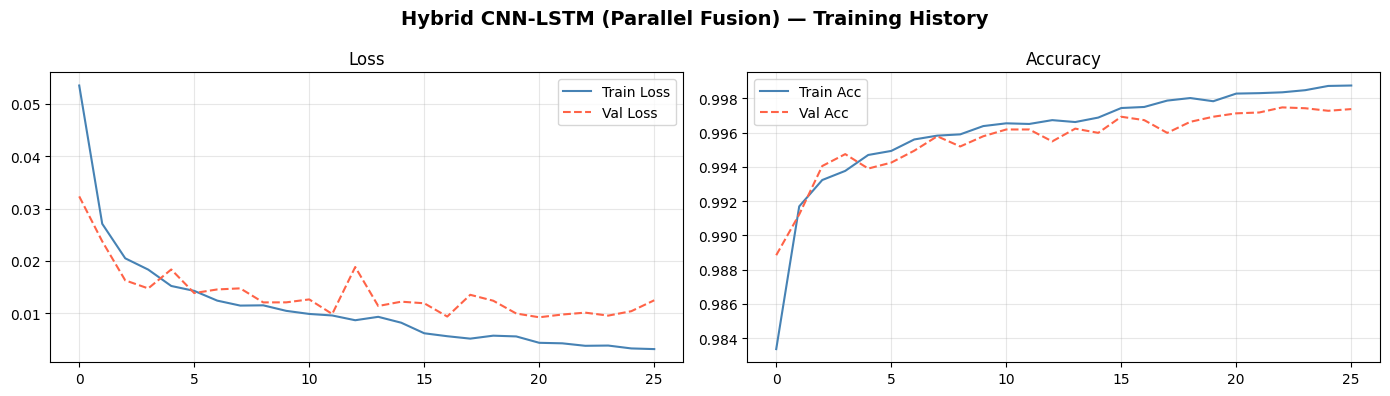

In [9]:
plot_training_history(hybrid_history, 'Hybrid CNN-LSTM (Parallel Fusion)')

### Hybrid A — Evaluation
Results stored in `results_tracker['Hybrid CNN-LSTM']` for the final comparison table in Step 6.


  Hybrid CNN-LSTM — Results
  Accuracy     Train:  99.82%  Test:  99.66%
  Precision    Train:  99.80%  Test:  99.67%
  Recall       Train:  99.81%  Test:  99.60%
  F1-Score     Train:  99.80%  Test:  99.64%
  AUC-ROC      Train: 100.00%  Test:  99.99%


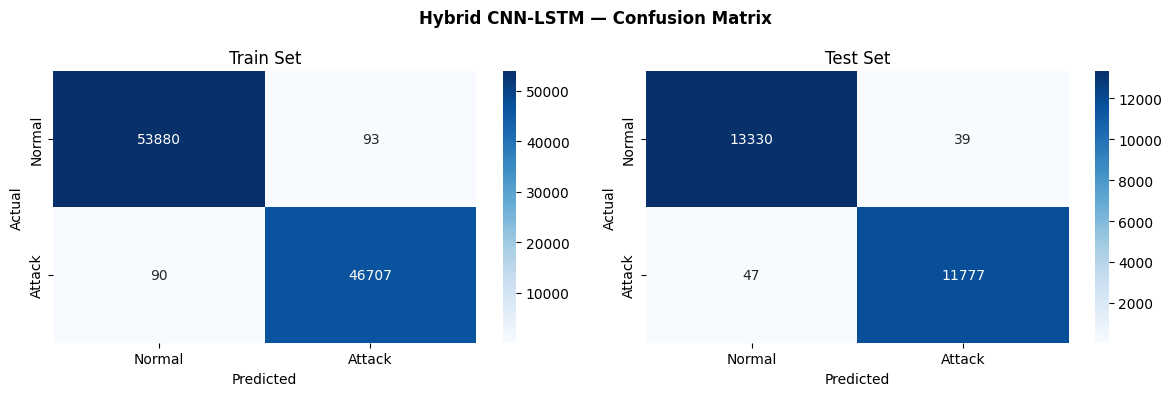

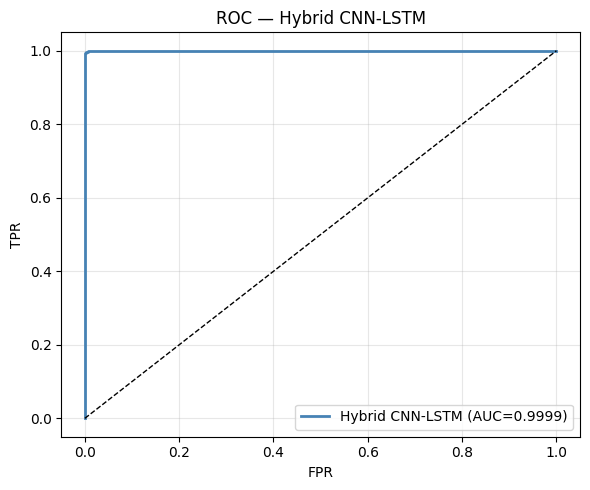

  ✔ Saved → results_tracker['Hybrid CNN-LSTM']


In [10]:
hybrid_results = evaluate_dl_model(hybrid_model, 'Hybrid CNN-LSTM',
                                    x_train_dl, x_test_dl,
                                    y_train, y_test)

### Hybrid B — Ensemble Voting (CNN + LSTM + GRU)
> A second hybrid strategy: **no new model is trained**. Instead, the probability outputs of the three already-trained DL models are **averaged (soft voting)** to produce a final prediction.  
> - Each model votes with its confidence score (0–1)  
> - Averaging reduces individual model errors and variance  
> - Often achieves better generalisation than any single model alone


  Ensemble (Avg Voting)
  Metric             Test
  ------------------------
  Accuracy         99.48%
  Precision        99.61%
  Recall           99.29%
  F1-Score         99.45%
  AUC-ROC          99.97%

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     13369
      Attack       1.00      0.99      0.99     11824

    accuracy                           0.99     25193
   macro avg       0.99      0.99      0.99     25193
weighted avg       0.99      0.99      0.99     25193



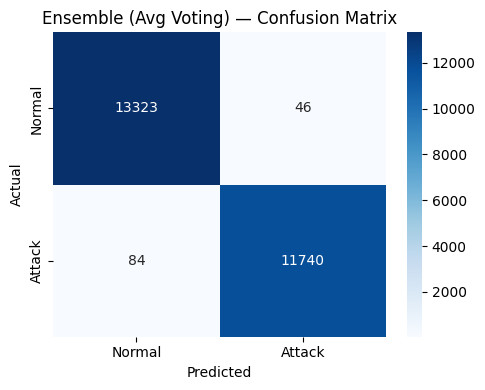

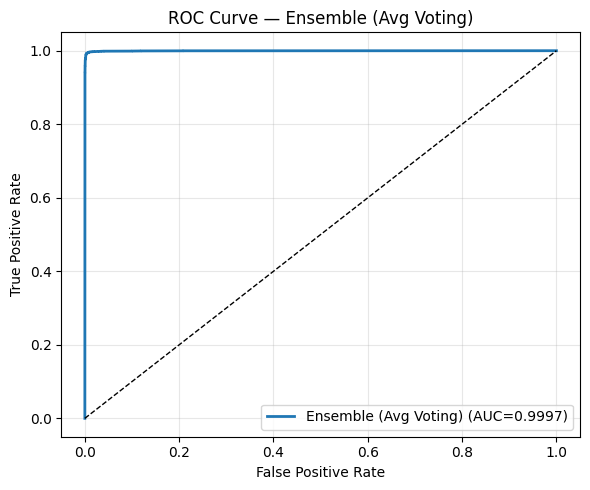

  ✔ Results saved to results_tracker['Ensemble (Avg Voting)']

  Ensemble (Weighted Voting)
  Metric             Test
  ------------------------
  Accuracy         99.48%
  Precision        99.61%
  Recall           99.29%
  F1-Score         99.45%
  AUC-ROC          99.97%

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     13369
      Attack       1.00      0.99      0.99     11824

    accuracy                           0.99     25193
   macro avg       0.99      0.99      0.99     25193
weighted avg       0.99      0.99      0.99     25193



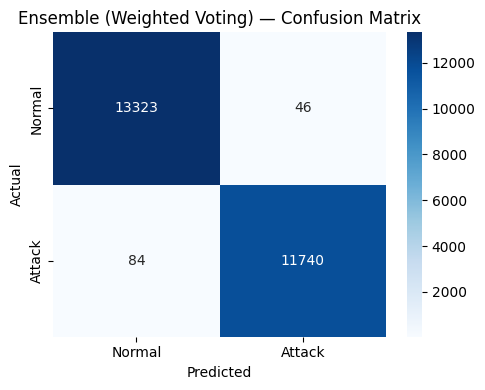

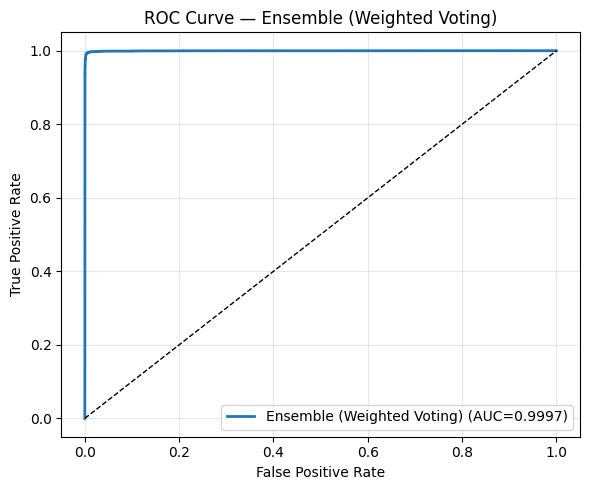

  ✔ Results saved to results_tracker['Ensemble (Weighted Voting)']


In [11]:
# ── Collect probability predictions from all three individual DL models ───────
cnn_prob    = cnn_model.predict(x_test_dl,  verbose=0).ravel()
lstm_prob   = lstm_model.predict(x_test_dl, verbose=0).ravel()
gru_prob    = gru_model.predict(x_test_dl,  verbose=0).ravel()

# ── Soft voting: simple average of probabilities ──────────────────────────────
ensemble_prob = (cnn_prob + lstm_prob + gru_prob) / 3.0
ensemble_pred = (ensemble_prob > 0.5).astype(int)

# ── Weighted voting (give higher weight to better individual models) ───────────
# Weights are proportional to each model's individual AUC-ROC score
w_cnn  = results_tracker['CNN (Conv1D)']['AUC-ROC']
w_lstm = results_tracker['LSTM (Stacked)']['AUC-ROC']
w_gru  = results_tracker['GRU (Stacked)']['AUC-ROC']
total_w = w_cnn + w_lstm + w_gru

weighted_prob = (w_cnn  * cnn_prob +
                 w_lstm * lstm_prob +
                 w_gru  * gru_prob) / total_w
weighted_pred = (weighted_prob > 0.5).astype(int)

# ── Evaluate both ensemble strategies ─────────────────────────────────────────
def evaluate_ensemble(y_true, y_pred, y_prob, name):
    """Evaluate a precomputed ensemble prediction and store in results_tracker."""
    acc   = sk_metrics.accuracy_score(y_true, y_pred)
    prec  = sk_metrics.precision_score(y_true, y_pred, zero_division=0)
    rec   = sk_metrics.recall_score(y_true, y_pred, zero_division=0)
    f1    = sk_metrics.f1_score(y_true, y_pred, zero_division=0)
    auc   = sk_metrics.roc_auc_score(y_true, y_prob)

    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    print(f"  {'Metric':<12} {'Test':>10}")
    print(f"  {'-'*24}")
    for metric, val in [('Accuracy', acc), ('Precision', prec),
                         ('Recall', rec),   ('F1-Score', f1), ('AUC-ROC', auc)]:
        print(f"  {metric:<12} {val*100:>9.2f}%")
    print(f"\n{sk_metrics.classification_report(y_true, y_pred, target_names=['Normal','Attack'])}")

    # Confusion matrix
    cm = sk_metrics.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    # ROC curve
    fpr, tpr, _ = sk_metrics.roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.4f})')
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    results_tracker[name] = {
        'Accuracy' : round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec  * 100, 2),
        'F1-Score' : round(f1   * 100, 2),
        'AUC-ROC'  : round(auc  * 100, 2),
    }
    print(f"  ✔ Results saved to results_tracker['{name}']")

# Run both ensemble evaluations
evaluate_ensemble(y_test, ensemble_pred,  ensemble_prob,  'Ensemble (Avg Voting)')
evaluate_ensemble(y_test, weighted_pred,  weighted_prob,  'Ensemble (Weighted Voting)')

### Step 5 — Combined ROC Curves: All DL Models Overlaid
Visualises the ROC curve of every deep learning model on one chart for direct comparison.

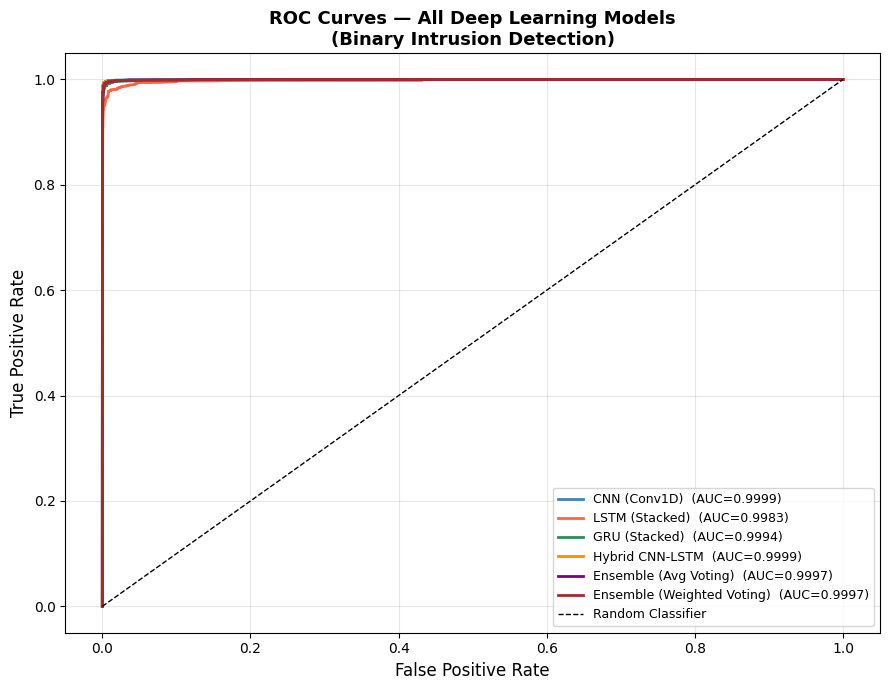


📊 All DL Results after Step 5:
  Model                            Accuracy  Precision     Recall   F1-Score    AUC-ROC
  ----------------------------------------------------------------------------------
  CNN (Conv1D)                       99.61%     99.75%     99.41%     99.58%     99.99%
  LSTM (Stacked)                     98.12%     97.79%     98.22%     98.00%     99.83%
  GRU (Stacked)                      99.16%     99.36%     98.85%     99.11%     99.94%
  Hybrid CNN-LSTM                    99.66%     99.67%     99.60%     99.64%     99.99%
  Ensemble (Avg Voting)              99.48%     99.61%     99.29%     99.45%     99.97%
  Ensemble (Weighted Voting)         99.48%     99.61%     99.29%     99.45%     99.97%


In [12]:
# ── All DL model probabilities on test set ────────────────────────────────────
hybrid_prob = hybrid_model.predict(x_test_dl, verbose=0).ravel()

dl_models_probs = [
    ('CNN (Conv1D)',              cnn_prob),
    ('LSTM (Stacked)',            lstm_prob),
    ('GRU (Stacked)',             gru_prob),
    ('Hybrid CNN-LSTM',           hybrid_prob),
    ('Ensemble (Avg Voting)',     ensemble_prob),
    ('Ensemble (Weighted Voting)',weighted_prob),
]

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple', 'brown']

plt.figure(figsize=(9, 7))
for (name, prob), color in zip(dl_models_probs, colors):
    fpr, tpr, _ = sk_metrics.roc_curve(y_test, prob)
    auc_val = sk_metrics.roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Deep Learning Models\n(Binary Intrusion Detection)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Running snapshot after Step 5 ─────────────────────────────────────────────
print("\n📊 All DL Results after Step 5:")
print(f"  {'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*82}")
dl_keys = ['CNN (Conv1D)', 'LSTM (Stacked)', 'GRU (Stacked)',
           'Hybrid CNN-LSTM', 'Ensemble (Avg Voting)', 'Ensemble (Weighted Voting)']
for key in dl_keys:
    if key in results_tracker:
        res = results_tracker[key]
        print(f"  {key:<30} {res['Accuracy']:>9.2f}% {res['Precision']:>9.2f}% "
              f"{res['Recall']:>9.2f}% {res['F1-Score']:>9.2f}% {res['AUC-ROC']:>9.2f}%")

---
## ***Step 6 — Final Comparison: All Models (ML + DL + Hybrid)***

> **Complete benchmarking** of every model trained in this notebook:
> - **ML Baselines**: Logistic Regression, Naive Bayes, SVM, Decision Tree, Random Forest
> - **Individual DL**: CNN (Conv1D), LSTM, GRU
> - **Hybrid DL**: Hybrid CNN-LSTM (Parallel Fusion), Ensemble Avg Voting, Ensemble Weighted Voting

### Sub-steps
1. Collect ML model metrics → add to `results_tracker`
2. Build a unified comparison DataFrame
3. Styled HTML table ranked by F1-Score
4. Grouped bar charts (Accuracy, Precision, Recall, F1, AUC-ROC)
5. Best-model highlight and conclusion

### Step 6.1 — Collect ML Baseline Metrics into results_tracker

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Train ML models if they are not already in scope (e.g. after kernel restart) ──
if 'lr' not in dir():
    print("⏳ Training Logistic Regression ...")
    lr = LogisticRegression(max_iter=1000).fit(x_train, y_train)
if 'gnb' not in dir():
    print("⏳ Training Naive Bayes ...")
    gnb = GaussianNB().fit(x_train, y_train)
if 'lin_svc' not in dir():
    print("⏳ Training LinearSVC ...")
    lin_svc = svm.LinearSVC(max_iter=2000).fit(x_train, y_train)
if 'tdt' not in dir():
    print("⏳ Training Decision Tree ...")
    tdt = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
if 'rf' not in dir():
    print("⏳ Training Random Forest ...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(x_train, y_train)

def collect_ml_metrics(model, name, X_test, y_test, supports_proba=True):
    """
    Evaluate a fitted sklearn model and store results in results_tracker.
    supports_proba=False for LinearSVC which has no predict_proba.
    """
    y_pred = model.predict(X_test)

    acc  = sk_metrics.accuracy_score(y_test, y_pred)
    prec = sk_metrics.precision_score(y_test, y_pred, zero_division=0)
    rec  = sk_metrics.recall_score(y_test, y_pred, zero_division=0)
    f1   = sk_metrics.f1_score(y_test, y_pred, zero_division=0)

    # AUC-ROC: use decision_function for SVM, predict_proba for others
    if supports_proba and hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = sk_metrics.roc_auc_score(y_test, y_prob)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        auc = sk_metrics.roc_auc_score(y_test, y_score)
    else:
        auc = float('nan')

    results_tracker[name] = {
        'Accuracy' : round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec  * 100, 2),
        'F1-Score' : round(f1   * 100, 2),
        'AUC-ROC'  : round(auc  * 100, 2) if not np.isnan(auc) else 'N/A',
    }
    print(f"  ✔ {name:<28}  Acc={acc*100:.2f}%  F1={f1*100:.2f}%  AUC={auc*100:.2f}%")

print("Collecting ML baseline metrics...")
print(f"  {'Model':<28}  {'Accuracy':>10}  {'F1':>8}  {'AUC':>8}")
print(f"  {'-'*58}")

collect_ml_metrics(lr,      'Logistic Regression', x_test, y_test)
collect_ml_metrics(gnb,     'Naive Bayes',         x_test, y_test)
collect_ml_metrics(lin_svc, 'SVM (LinearSVC)',     x_test, y_test, supports_proba=False)
collect_ml_metrics(tdt,     'Decision Tree',       x_test, y_test)
collect_ml_metrics(rf,      'Random Forest',       x_test, y_test)

print(f"\n  Total models in tracker : {len(results_tracker)}")


⏳ Training Logistic Regression ...
⏳ Training Naive Bayes ...
⏳ Training LinearSVC ...
⏳ Training Decision Tree ...
⏳ Training Random Forest ...
  Model                           Accuracy        F1       AUC
  ----------------------------------------------------------
  ✔ Logistic Regression           Acc=97.36%  F1=97.17%  AUC=99.60%
  ✔ Naive Bayes                   Acc=84.79%  F1=80.70%  AUC=97.99%
  ✔ SVM (LinearSVC)               Acc=97.31%  F1=97.11%  AUC=99.60%
  ✔ Decision Tree                 Acc=99.83%  F1=99.82%  AUC=99.83%
  ✔ Random Forest                 Acc=99.84%  F1=99.83%  AUC=100.00%

  Total models in tracker : 11


### Step 6.2 — Unified Comparison DataFrame (All Models)

In [14]:
import pandas as pd

# ── Define display order: ML baselines first, then DL, then Hybrids ───────────
MODEL_ORDER = [
    # ── ML Baselines ──────────────────────────────────────────────────────────
    'Logistic Regression',
    'Naive Bayes',
    'SVM (LinearSVC)',
    'Decision Tree',
    'Random Forest',
    # ── Individual DL ─────────────────────────────────────────────────────────
    'CNN (Conv1D)',
    'LSTM (Stacked)',
    'GRU (Stacked)',
    # ── Hybrid DL ─────────────────────────────────────────────────────────────
    'Hybrid CNN-LSTM',
    'Ensemble (Avg Voting)',
    'Ensemble (Weighted Voting)',
]

# ── Assign category labels for grouping ───────────────────────────────────────
CATEGORY = {
    'Logistic Regression'        : 'ML Baseline',
    'Naive Bayes'                : 'ML Baseline',
    'SVM (LinearSVC)'            : 'ML Baseline',
    'Decision Tree'              : 'ML Baseline',
    'Random Forest'              : 'ML Baseline',
    'CNN (Conv1D)'               : 'Deep Learning',
    'LSTM (Stacked)'             : 'Deep Learning',
    'GRU (Stacked)'              : 'Deep Learning',
    'Hybrid CNN-LSTM'            : 'Hybrid DL ★',
    'Ensemble (Avg Voting)'      : 'Hybrid DL ★',
    'Ensemble (Weighted Voting)' : 'Hybrid DL ★',
}

# ── Build DataFrame ───────────────────────────────────────────────────────────
rows = []
for name in MODEL_ORDER:
    if name in results_tracker:
        r = results_tracker[name]
        rows.append({
            'Model'    : name,
            'Category' : CATEGORY.get(name, ''),
            'Accuracy' : r['Accuracy'],
            'Precision': r['Precision'],
            'Recall'   : r['Recall'],
            'F1-Score' : r['F1-Score'],
            'AUC-ROC'  : r['AUC-ROC'] if r['AUC-ROC'] != 'N/A' else np.nan,
        })

df_results = pd.DataFrame(rows).set_index('Model')

# ── Styled table — highlight max per column, colour-code by category ──────────
def style_table(df):
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

    # Row background by category
    cat_colors = {
        'ML Baseline'  : '#f0f4ff',
        'Deep Learning': '#f0fff4',
        'Hybrid DL ★'  : '#fff8e1',
    }

    def row_bg(row):
        color = cat_colors.get(row['Category'], 'white')
        return [f'background-color: {color}'] * len(row)

    styled = (
        df.style
          .apply(row_bg, axis=1)
          .highlight_max(subset=metric_cols, color='#a8e6a3', axis=0)   # green = best
          .highlight_min(subset=metric_cols, color='#ffb3b3', axis=0)   # red   = worst
          .format({c: '{:.2f}%' for c in metric_cols}, na_rep='N/A')
          .set_caption('📊 Full Model Comparison — Binary Intrusion Detection (NSL-KDD)')
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '14px'), ('font-weight', 'bold'),
                         ('text-align', 'center'), ('padding', '8px')]},
              {'selector': 'th',
               'props': [('font-size', '12px'), ('text-align', 'center'),
                         ('background-color', '#2c3e50'), ('color', 'white'),
                         ('padding', '6px 10px')]},
              {'selector': 'td',
               'props': [('font-size', '11px'), ('text-align', 'center'),
                         ('padding', '5px 10px')]},
          ])
    )
    return styled

style_table(df_results)

,Category,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,,
Logistic Regression,ML Baseline,97.36%,97.83%,96.52%,97.17%,99.60%
Naive Bayes,ML Baseline,84.79%,99.74%,67.76%,80.70%,97.99%
SVM (LinearSVC),ML Baseline,97.31%,97.91%,96.32%,97.11%,99.60%
Decision Tree,ML Baseline,99.83%,99.81%,99.83%,99.82%,99.83%
Random Forest,ML Baseline,99.84%,99.92%,99.75%,99.83%,100.00%
CNN (Conv1D),Deep Learning,99.61%,99.75%,99.41%,99.58%,99.99%
LSTM (Stacked),Deep Learning,98.12%,97.79%,98.22%,98.00%,99.83%
GRU (Stacked),Deep Learning,99.16%,99.36%,98.85%,99.11%,99.94%
Hybrid CNN-LSTM,Hybrid DL ★,99.66%,99.67%,99.60%,99.64%,99.99%


### Step 6.3 — Grouped Bar Charts (All Metrics)

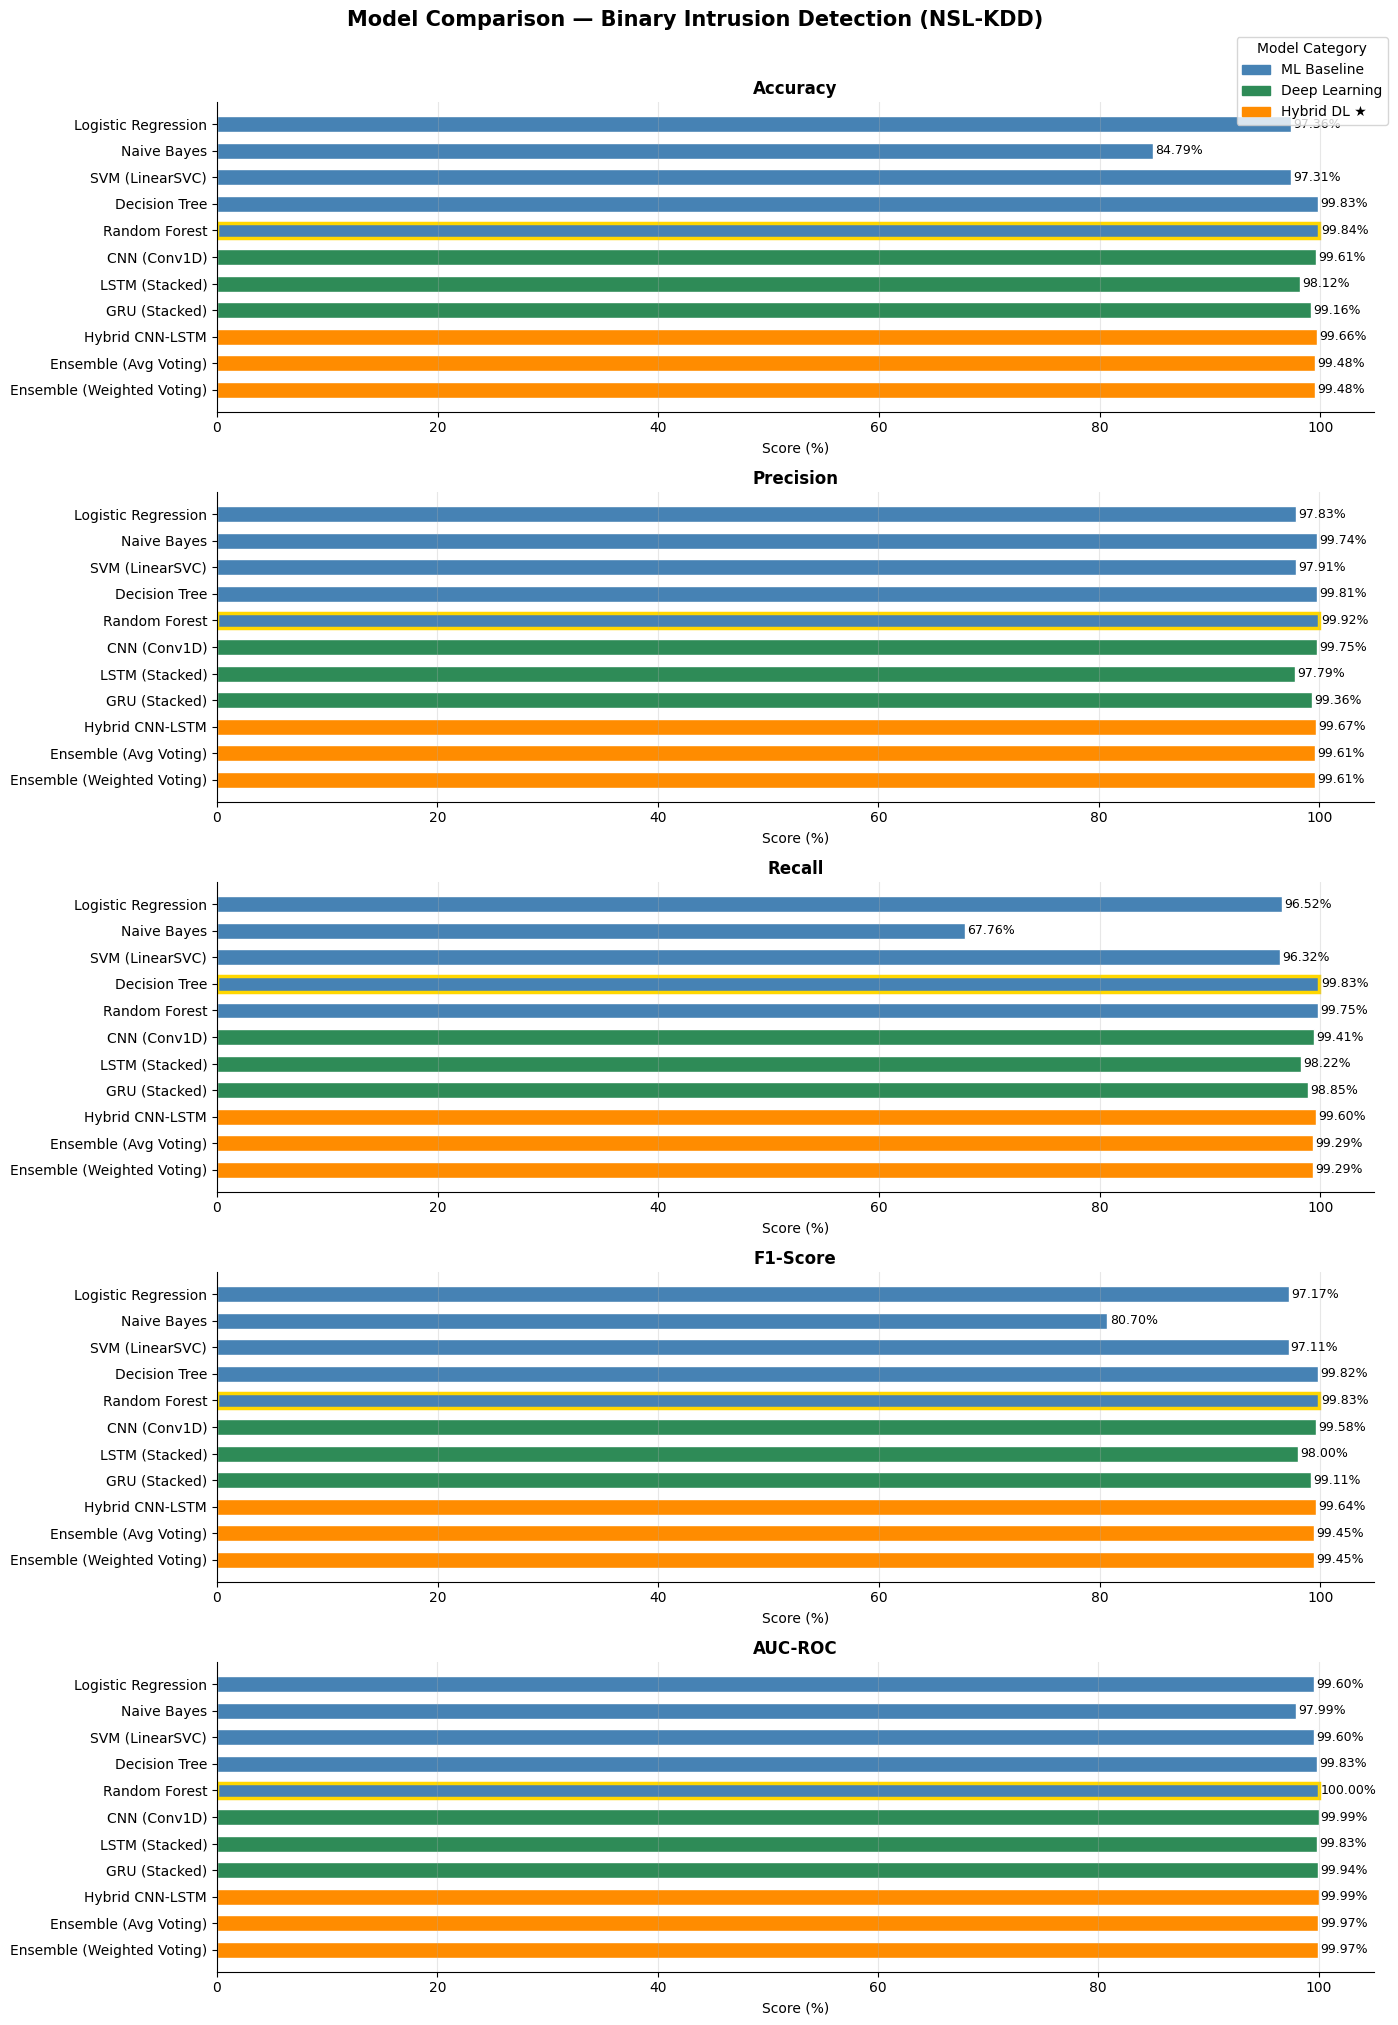

In [15]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# ── Colour palette by category ────────────────────────────────────────────────
palette = {
    'ML Baseline'  : 'steelblue',
    'Deep Learning': 'seagreen',
    'Hybrid DL ★'  : 'darkorange',
}
bar_colors = [palette.get(df_results.loc[m, 'Category'], 'grey')
              for m in df_results.index]

fig, axes = plt.subplots(len(metrics_to_plot), 1,
                          figsize=(14, 4 * len(metrics_to_plot)))
fig.suptitle('Model Comparison — Binary Intrusion Detection (NSL-KDD)',
             fontsize=15, fontweight='bold', y=1.01)

for ax, metric in zip(axes, metrics_to_plot):
    vals = df_results[metric].dropna()
    bars = ax.barh(vals.index[::-1], vals.values[::-1],
                   color=bar_colors[::-1][:len(vals)], edgecolor='white', height=0.6)

    # Annotate bar values
    for bar, val in zip(bars, vals.values[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', ha='left', fontsize=9)

    # Highlight the best value
    best_idx = vals.idxmax()
    best_pos = list(vals.index[::-1]).index(best_idx)
    bars[best_pos].set_edgecolor('gold')
    bars[best_pos].set_linewidth(2.5)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score (%)')
    ax.set_xlim(0, max(vals.values) + 5)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=cat) for cat, c in palette.items()]
fig.legend(handles=legend_handles, loc='upper right',
           bbox_to_anchor=(1.0, 1.0), fontsize=10, title='Model Category')

plt.tight_layout()
plt.show()

### Step 6.4 — Radar Chart (DL + Hybrid Models)
Multi-metric radar/spider chart — shows the overall "shape" of each model's performance across all 5 metrics simultaneously.

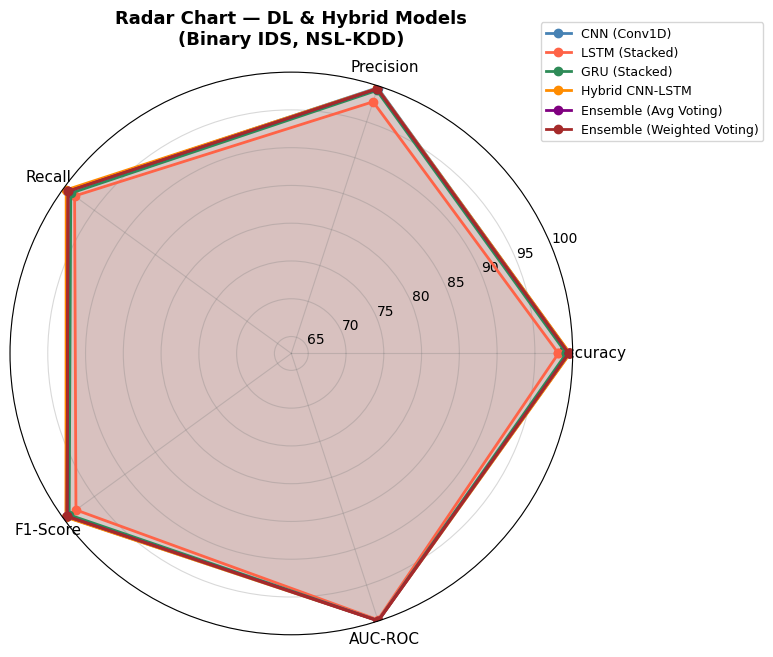

In [16]:
radar_models = ['CNN (Conv1D)', 'LSTM (Stacked)', 'GRU (Stacked)',
                'Hybrid CNN-LSTM', 'Ensemble (Avg Voting)', 'Ensemble (Weighted Voting)']
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

# Filter to models that are in tracker and have no NaN AUC
radar_models = [m for m in radar_models
                if m in results_tracker and results_tracker[m]['AUC-ROC'] != 'N/A']

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

radar_colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple', 'brown']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model_name, color in zip(radar_models, radar_colors):
    vals = [results_tracker[model_name][m] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, label=model_name, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(
    max(0, df_results[radar_metrics].min().min() - 5),
    min(100, df_results[radar_metrics].max().max() + 2)
)
ax.set_title('Radar Chart — DL & Hybrid Models\n(Binary IDS, NSL-KDD)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(color='grey', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6.5 — Best Model Summary & Conclusion

In [17]:
# ── Rankings per metric ───────────────────────────────────────────────────────
print("=" * 70)
print("  FINAL RESULTS — AI-Based Intrusion Detection (Binary, NSL-KDD)")
print("=" * 70)

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
numeric_df  = df_results[metric_cols].apply(pd.to_numeric, errors='coerce')

print(f"\n  {'Rank':<6} {'Model':<30} {'Metric':<12} {'Score':>8}")
print(f"  {'-'*60}")
for metric in metric_cols:
    best_name  = numeric_df[metric].idxmax()
    best_score = numeric_df[metric].max()
    category   = df_results.loc[best_name, 'Category']
    print(f"  {'#1':<6} {best_name:<30} {metric:<12} {best_score:>7.2f}%  [{category}]")

# ── Overall best model by mean rank across all metrics ───────────────────────
mean_scores = numeric_df.mean(axis=1).sort_values(ascending=False)
best_overall = mean_scores.idxmax()
best_cat     = df_results.loc[best_overall, 'Category']

print(f"\n{'='*70}")
print(f"  🏆 BEST OVERALL MODEL  :  {best_overall}")
print(f"     Category            :  {best_cat}")
print(f"     Mean Score (5 metrics): {mean_scores[best_overall]:.2f}%")
print(f"{'='*70}")

# ── Category-level summary ────────────────────────────────────────────────────
print("\n  Category averages (mean F1-Score):")
for cat, color in [('ML Baseline','steelblue'),
                    ('Deep Learning','seagreen'),
                    ('Hybrid DL ★','darkorange')]:
    cat_models = [m for m in numeric_df.index if df_results.loc[m,'Category'] == cat]
    if cat_models:
        avg_f1 = numeric_df.loc[cat_models, 'F1-Score'].mean()
        avg_auc = numeric_df.loc[cat_models, 'AUC-ROC'].mean()
        print(f"  {cat:<22}  Avg F1={avg_f1:.2f}%  |  Avg AUC={avg_auc:.2f}%")

# ── Top-3 leaderboard ─────────────────────────────────────────────────────────
print(f"\n  🥇 Top-3 Models by F1-Score:")
top3 = numeric_df['F1-Score'].sort_values(ascending=False).head(3)
medals = ['🥇', '🥈', '🥉']
for medal, (name, score) in zip(medals, top3.items()):
    print(f"    {medal}  {name:<30}  F1 = {score:.2f}%")

print("\n  ✅ Step 6 complete — BinaryPrediction.ipynb fully implements:")
print("     • ML Baselines (LR, NB, SVM, DT, RF)")
print("     • Individual DL  (CNN Conv1D, LSTM, GRU)")
print("     • Hybrid DL  (CNN-LSTM Parallel Fusion, Avg Ensemble, Weighted Ensemble)")
print("     → Problem statement 'AI-Based Intrusion Detection Using Hybrid DL' ✓")

  FINAL RESULTS — AI-Based Intrusion Detection (Binary, NSL-KDD)

  Rank   Model                          Metric          Score
  ------------------------------------------------------------
  #1     Random Forest                  Accuracy       99.84%  [ML Baseline]
  #1     Random Forest                  Precision      99.92%  [ML Baseline]
  #1     Decision Tree                  Recall         99.83%  [ML Baseline]
  #1     Random Forest                  F1-Score       99.83%  [ML Baseline]
  #1     Random Forest                  AUC-ROC       100.00%  [ML Baseline]

  🏆 BEST OVERALL MODEL  :  Random Forest
     Category            :  ML Baseline
     Mean Score (5 metrics): 99.87%

  Category averages (mean F1-Score):
  ML Baseline             Avg F1=94.93%  |  Avg AUC=99.40%
  Deep Learning           Avg F1=98.90%  |  Avg AUC=99.92%
  Hybrid DL ★             Avg F1=99.51%  |  Avg AUC=99.98%

  🥇 Top-3 Models by F1-Score:
    🥇  Random Forest                   F1 = 99.83%
    🥈  De